# Datasets from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/)

First, we import the libraries that we will need to load, process and visualize the data.

Details about the different libraries and provided functions can be found in their respective documentation:
- `numpy` for numerical calculations https://numpy.org/doc/stable/
- `pandas` for data manipulation and analysis https://pandas.pydata.org/docs/
- `pyplot` from `matplotlib` for basic plotting functionalities https://matplotlib.org/stable/
- `seaborn` for data visualization https://seaborn.pydata.org/

The first line below is a Python 'magic command' to display the plots in the notebook.
The last line is to somewhat increase the default figure width.

In [1]:
%matplotlib inline
import numpy
import pandas
import matplotlib.pyplot as plt
import seaborn

plt.rcParams["figure.figsize"] = (10, 5)

We write a function to list the columns that have missing values in a given dataset, or report that there are none.

In [2]:
def check_missing_values(dtf):
    cols_missing_values = [c for c in dtf if dtf[c].isna().any()]
    if len(cols_missing_values) > 0:
        print("\n\t- ".join(
            ["The following %s columns contain missing values:" % len(cols_missing_values)]+
            cols_missing_values))
    else:
        print("No values are missing.")

## *Iris* dataset

The [*Iris* dataset](https://archive.ics.uci.edu/dataset/53/iris) is the main example dataset used in part I of the course.

This dataset contains physical measurements of iris flowers, as the predictive attributes, accompanied by the indication of the species each specimen belongs to, as the class.

In particular, from the [dataset description](https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.names) we can find the list of attributes:


| Name | Unit |
| ---- | ---- |
| sepal length | cm |
| sepal width  | cm |
| petal length | cm |
| petal width  | cm |
| **class** | 'Iris-setosa', 'Iris-versicolor' or 'Iris-virginica' |


The classification task typically considered is to predict the species of a flower specimen based on its physical measurements.

We load the data from the `iris.data` file. This file does not contain names for the columns, so we provide them as the `names` input parameter to the `read_csv` function.

In [3]:
iris_path = "./iris/iris.data"
cnames = ["SepalLength", "SepalWidth", "PetalLength", "PetalWidth", "Class"]
iris_dtf = pandas.read_csv(iris_path, sep=",", names=cnames)

The iris species, recorded in column `Class`, is the classification target. We obtain the counts of specimens of each species, i.e. we tally the occurrences of each value in the `Class` column.

In [4]:
iris_targetname = "Class"
iris_dtf.value_counts(iris_targetname)

Class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

We see that the dataset contains three different classes, corresponding each to an iris species, and that the classes are perfectly balanced, with exactly fifty samples each.

We show descriptive statistics. The `Class` variable, containing strings, is automatically excluded by default.

Since all four predictive attributes are numerical,  for each of them the summary includes the number of values (`count`, which is equal to the number of samples since no values are missing), the average value (`mean`), the standard deviation (`std`), the minimum and maximum values (`min` and `max`, respectively), as well as the 25th, 50th and 75th percentiles (`25%`, `50%` and `75%`, respectively).

Recall that the *x*th percentile is the threshold such that *x* percent of values fall below it. In particular, the 50th percentile is the threshold such that fifty percent of values fall below it, and hence half of values are above. It is also known as the *median*.

In [5]:
iris_dtf.describe()

,SepalLength,SepalWidth,PetalLength,PetalWidth
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


Sepals and petals are on average clearly longer than they are wide, with sepals on average larger than petals.

We show an outline of the dataset, displaying the first and last few rows.

In [6]:
iris_dtf

,SepalLength,SepalWidth,PetalLength,PetalWidth,Class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


Finally, we visualize the dataset with *seaborn*'s `pairplot` function.

It generates a scatter plot of each of the four predictive attributes against each other predictive attribute, where each dot represents an iris specimen, arranged into a grid. The plots along the diagonal of the grid represent the distribution of the values for the corresponding attribute considered separately. The three iris species are depicted with the same three colors as in the course material.

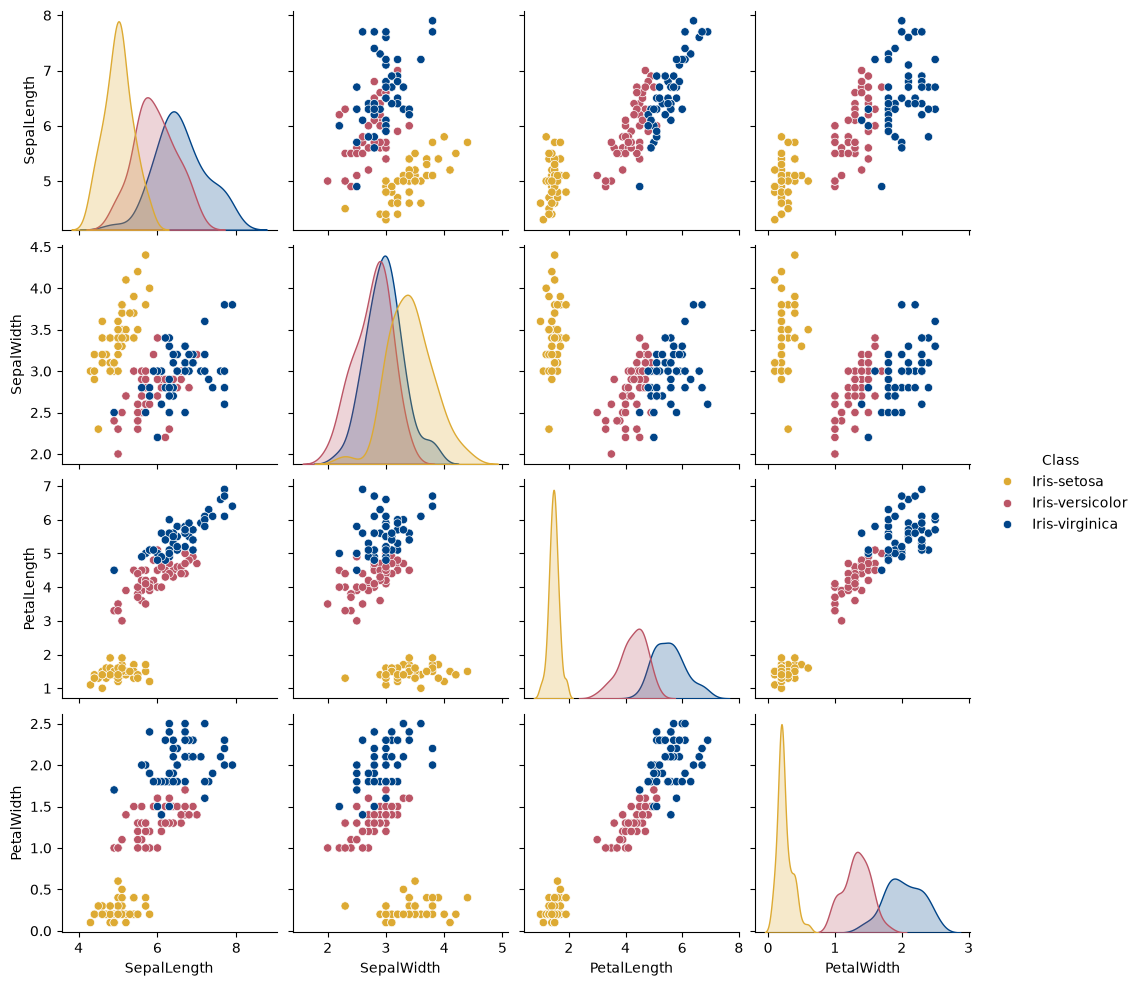

In [7]:
# Create an array with the colors for the different species
species_to_colors = {"Iris-setosa":"#DDAA33", "Iris-versicolor": "#BB5566", "Iris-virginica": "#004488"}
species = sorted(pandas.unique(iris_dtf[iris_targetname]))
iris_palette = seaborn.color_palette([species_to_colors[s] for s in species])

seaborn.pairplot(iris_dtf, hue=iris_targetname, hue_order=species, palette=iris_palette);

In all scatter plots, the clouds of yellow points, representing specimens of *Iris setosa*, are always clearly separated, whereas the clouds of red and blue points, representing respectively specimens of *Iris versicolor* and of *Iris viginica*, show some overlap for all pairs of dimensions and especially in the *sepal length* vs. *sepal width* plot.

The density plots along the diagonal show that *Iris setosa*, in yellow, are typically smaller on all dimensions, except sepal width, where they are on average slightly larger than the other two species. Furthermore, when compared to the other species, the dimensions of the petals of *Iris setosa* specimens do not vary much, with both curves showing a large peak.

Considering the task of classifying iris specimens in this dataset based on their physical measurements, it seems that *Iris setosa* specimens should be relatively easy to identify, while *Iris versicolor* and *Iris viginica* specimens might be more difficult to tell apart, since they have more similar sizes.

## *Glass Identification* dataset

The [*Glass Identification* dataset](https://archive.ics.uci.edu/dataset/42/glass+identification) contains information about the chemical properties of glass samples and the task typically considered is to predict the type of glass of each sample.
Indeed, according to the [dataset description](https://archive.ics.uci.edu/ml/machine-learning-databases/glass/glass.names),

> the study of classification of types of glass was motivated by criminological investigation.  At the scene of the crime, the glass left can be used as evidence...if it is correctly identified!

The descriptive attributes are the [refractive index (RI)](https://en.wikipedia.org/wiki/Refractive_index) and the weight percent in the different oxides that constitute glass, namely in

| Na | Mg | Al | Si | K | Ca | Ba | Fe |
| ---- | ---- |---- | ---- |---- | ---- |---- | ---- |
| Sodium | Magnesium | Aluminum | Silicon | Potassium | Calcium | Barium | Iron |


The last column contains integer values representing the type of glass of the samples, as follows

- **1**: building_windows_float_processed
- **2**: building_windows_non_float_processed
- **3**: vehicle_windows_float_processed
- **4**: vehicle_windows_non_float_processed (none in this database)
- **5**: containers
- **6**: tableware
- **7**: headlamps

[*Float glass*](https://en.wikipedia.org/wiki/Float_glass) refers to a sheet of glass produced following a special process introduced in the 1950's to ensure a uniform thickness and a very flat surface.

We load the data from the `glass.data` file. This file does not contain names for the columns, so we provide it as the `names` input parameter to the `read_csv` function. We use the first column, the `Id` column, as index. The type of glass, recorded in column `Type`, is the target variable.

In [8]:
glass_path = "./glass+identification/glass.data"
cnames = ["Id", "RI", "Na", "Mg", "Al", "Si", "K", "Ca", "Ba", "Fe", "Type"]
glass_targetname = "Type"
glass_dtf = pandas.read_csv(glass_path, sep=",", names=cnames, index_col="Id")

We use our custom function to check whether there are any missing values.

In [9]:
check_missing_values(glass_dtf)

No values are missing.


We show an outline of the dataset, displaying the first and last few rows.

In [10]:
glass_dtf

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
Id,,,,,,,,,,
1,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,1
2,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,1
3,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,1
4,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,1
5,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,1
...,...,...,...,...,...,...,...,...,...,...
210,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,7
211,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,7
212,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,7


We make a histogram showing the number of samples of each glass type.

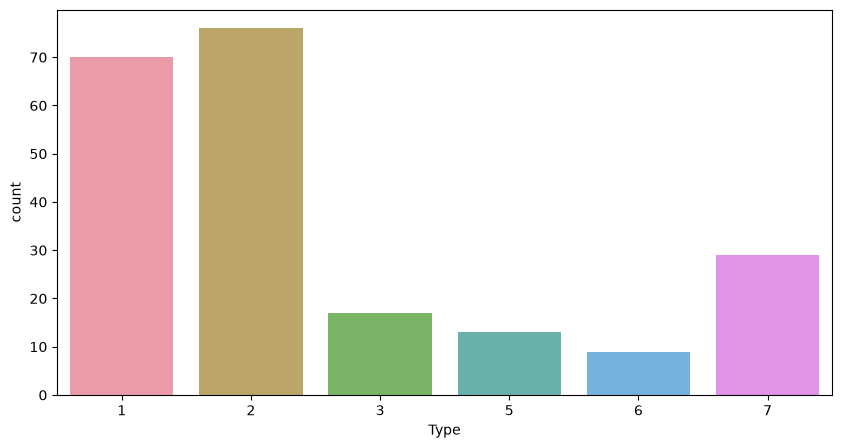

In [11]:
glass_palette = seaborn.color_palette("husl", len(pandas.unique(glass_dtf[glass_targetname])))
seaborn.countplot(data=glass_dtf, x=glass_targetname, hue=glass_targetname,
                 palette=glass_palette, alpha=0.8, legend=None);

The distribution of samples across the different glass types if clearly not uniform. The vast majority of samples come from building windows, produced using the float glass process (type 1) or otherwise (type 2). The third most frequent type consists of glass from headlamps (type 7). Next comes float glass from vehicle windows (type 3), followed by glass from containers (type 5) and from tableware (type 6). There are no samples from vehicle windows that are not float glass (type 4) in this dataset.

For each sample, we sum the weight percents across the eight different oxides, and check the range of the resulting values.

In [12]:
totals = glass_dtf[["Na", "Mg", "Al", "Si", "K", "Ca", "Ba", "Fe"]].sum(axis=1)
print(f"The sum of weight percents across the different oxides is between {totals.min():.2f} and {totals.max():.2f}")

The sum of weight percents across the different oxides is between 99.02 and 100.10


Up to rounding errors, the weight percents sum to a hundred, which makes sense.
That also means that the values are not independent, we could drop one of the oxides and recalculate its weight percents from the remaining seven.

We show descriptive statistics, excluding the `Type` column by name. Indeed, although this column contains numerical values, they represent categories and the order between the values is not actually meaningful.

For the refractive index and each oxide, the summary includes the number of values (`count`, which is equal to the number of samples since no values are missing), the average value (`mean`), the standard deviation (`std`), the minimum and maximum values (`min` and `max`, respectively), as well as the 25th, 50th and 75th percentiles (`25%`, `50%` and `75%`, respectively).

In [13]:
glass_dtf.drop(columns="Type").describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000


The refractive index (RI) takes values between 1.511 and 1.534. The main component of glass is silicon (Si, not to be confused with silicone), making up between two-third and three-quarters of the weight of the samples. Sodium (Na) and calcium (Ca) are the next most common components of glass, followed by aluminum (Al), all three of which are present in all samples, albeit in varying amounts. On the other hand, magnesium (Mg), potassium (K), barium (Ba) and iron (Fe) are present in small quantities in some samples and absent from others, as visible from the minimum value (min) equal to zero in each of the corresponding four columns.

Next, we plot the correlation matrix, showing the correlation between every pair of attributes. We sort the rows and columns by the absolute value of the correlation with the target, so that attributes that are more strongly correlated with the type of glass, either positively or negatively, come first when going from the top to the bottom and from the left to the right of the matrix.

We use the `coolwarm` color map, scaled from -1 to 1, the full range of possible correlations, so that bright blue and red represent respectively strong negative and strong positive correlations, while intermediate correlation values are depicted with more muted shades, with gray indicating a correlation equal to zero, i.e. a pair of variables that are not linearly dependent.

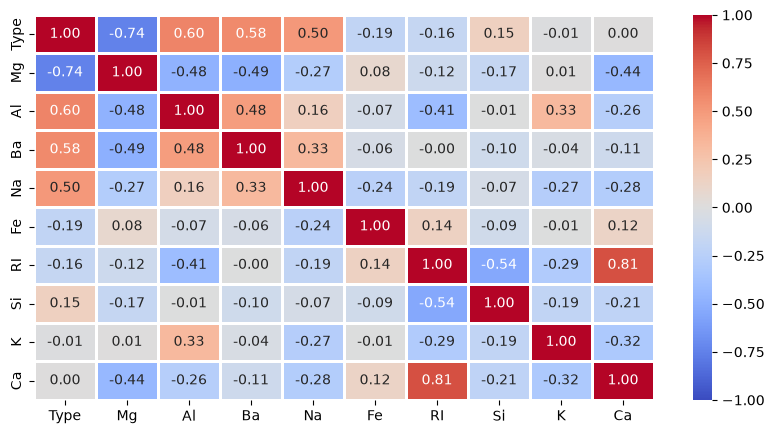

In [14]:
crm = glass_dtf.corr()
sorted_columns = crm[glass_targetname].abs().sort_values(ascending=False).index
sorted_features = sorted_columns[1:]
seaborn.heatmap(crm.loc[sorted_columns,sorted_columns], linewidth=.8, vmin=-1, vmax=1,
                annot=True, fmt=".2f", cmap="coolwarm");

Magnesium (Mg) has a fairly strong negative correlation with the glass type (-0.74), whereas aluminum (Al), barium (Ba) and potassium (K) are positively correlated with the glass type (0.60, 0.58 and 0.50, respectively). This indicates that glass of types denoted with small integers contain relatively higher percentages of magnesium and lower percentages of aluminum, barium and potassium as compared to glass of types denoted with larger integers. Obviously, this depends on the code used to represent types of glass, which is essentially arbitrary, as far as we can tell.

We can also see that the refractive index (RI) has a strong positive correlation with the amount of calcium (Ca, 0.81) and a more limited negative correlation with the amount of silicon (Si, -0.54).

We show the distribution of values for the refractive index and each of the eight oxides, with a separate boxplot for each glass type.
We keep the attributes sorted by decreasing absolute correlations with the type of glass.

When using the defaults parameters for drawing [boxplots](https://en.wikipedia.org/wiki/Box_plot), each box spans from the *lower quartile* (also first quartile *Q1*, or 25th percentile) to the *upper quartile* (also third quartile *Q3*, or 75th percentile). The difference between the two, corresponding to the height of the box, is known as the *interquartile range* (*IR*). *Wiskers*, spanning below and above the box, correspond respectively to the lower quartile minus one and a half interquartile range (*Q1 - 1.5 IR*) and the upper quartile plus one and a half interquartile range (*Q3 + 1.5 IR*). Values outside of that range are typically considered to be outliers, depicted as circles and known as *fliers*. The line inside the box represents the *median* (also second quartile *Q2*, or 50th percentile), i.e. the middle value.

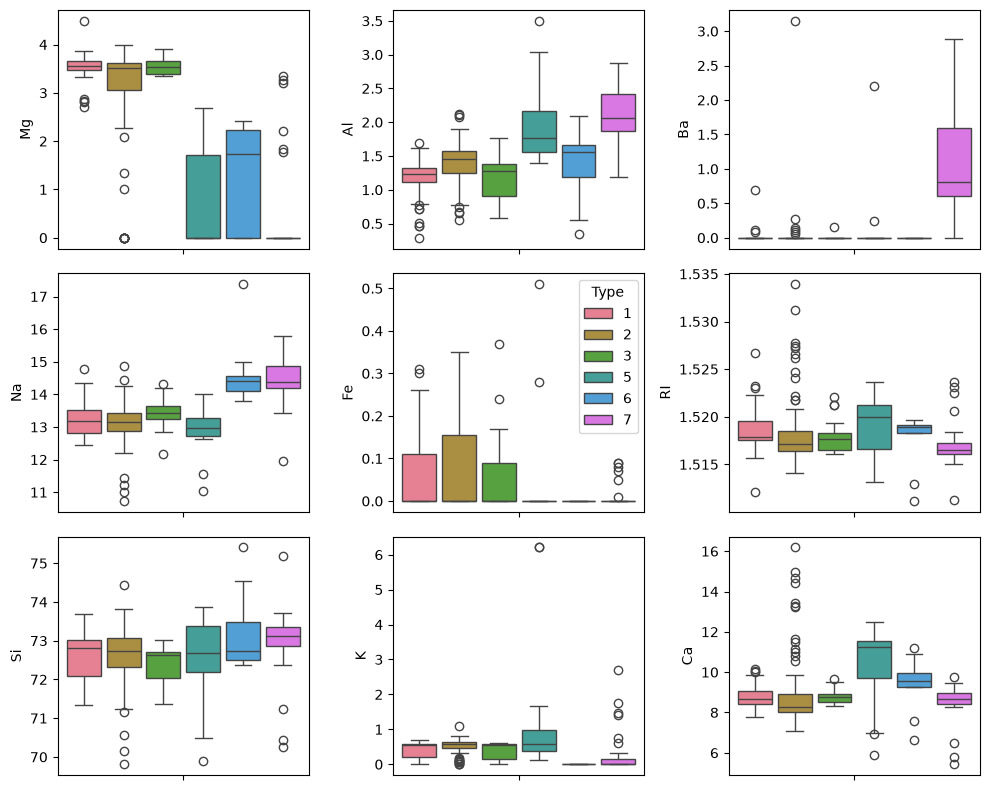

In [15]:
f, axes = plt.subplots(len(sorted_features)//3, 3)
for ci, c in enumerate(sorted_features):
    seaborn.boxplot(glass_dtf, y=c, hue=glass_targetname,
                    ax=axes[ci//3, ci%3], width=0.95, dodge=True, gap=0.15,
                    palette=glass_palette, legend=(ci==4))
f.set_figheight(8)
f.tight_layout()

Comparing the scale of the vertical axis of the middle panel to other panels, we see that it has the smallest values, indicating that iron (Fe) is only present in very small amounts if at all.
The median value of iron (Fe) weight percent (indicated by a line inside the box) is zero for all glass types. The third quartile (or 75th percentile, corresponding to the upper end of the box) is non zero for types 1, 2 and 3 and zero for types 5, 6 and 7. Few samples have exceptionally high values, depicted with circles as fliers.
In summary, iron is present in less than half of the samples from building and vehicle windows (types 1, 2 and 3) and absent from samples from other types of glass, with few exceptions.

Magnesium (Mg) is clearly more present in samples from building and vehicle windows (types 1, 2 and 3). Sodium (Na) is more present in samples from tableware and headlamps (types 6 and 7). Aluminum is also over-represented in samples from headlamps (type 7) but also, to a lower extent, in samples from containers (type 5), whereas barium (Ba) is only present in headlamp glass (type 7). This explains the correlations observed previously between these oxides weight percents and the type of glass.

Calcium (Ca) is over-represented in samples from containers (type 5).
The distribution of calcium (Ca) and refractive index (RI) are very similar, as could be expected from the high positive correlation.

The median value of silicon (Si) weight percent is almost the same for all glass types, about 72.8, the median value of potassium (K) weight percent is very similar among building and vehicle windows (types 1, 2 and 3) as well as containers (type 5), around 0.75.

Finally, we show some scatter plots. It would be overwhelming to display plots for all pairs of attributes. Instead, we show scatter plots for attributes that are strongly correlated with the type of glass, as columns in the grid of plots, against attributes that are more weakly correlated with it, as rows.

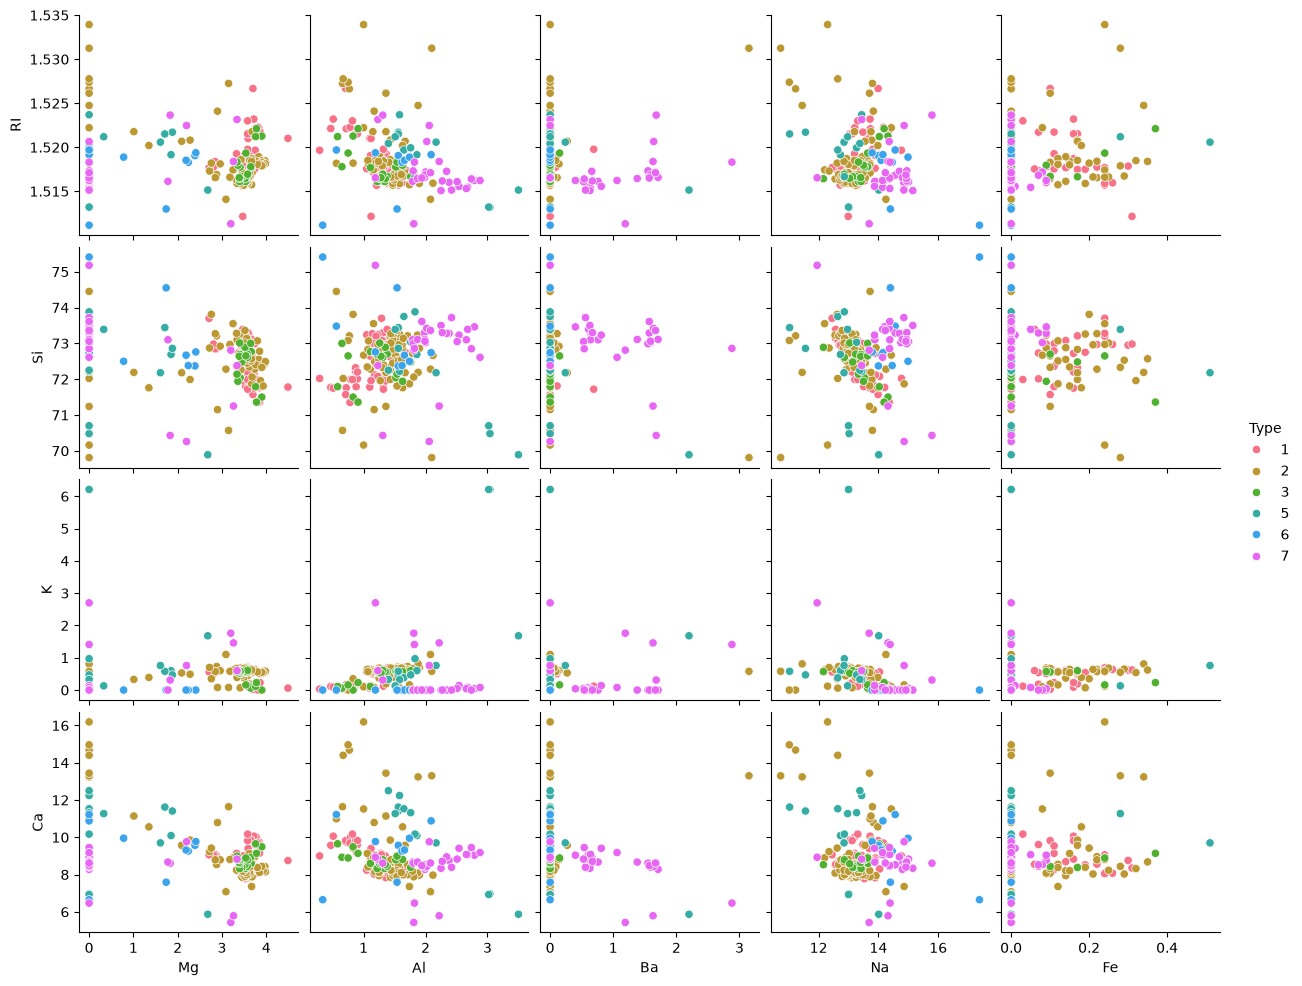

In [16]:
seaborn.pairplot(glass_dtf, hue=glass_targetname, x_vars=sorted_features[:5], y_vars=sorted_features[5:],
                palette=glass_palette);

A large number of points are aligned horizontally at zero for plots where the x-axis represents either magnesium (Mg), barium (Ba) or iron (Fe) weight percent, showing the large number of samples where these oxides are absent.

Overall, the scatter plots do not provide much information about the distribution of values beyond what we previously observed. In particular, they do not reveal any clear cluster structure.

## *Heart Failure* dataset

The [*Heart Failure* dataset](https://archive.ics.uci.edu/dataset/519/heart+failure+clinical+records) belongs to the area of health and medicine, containing medical records of heart failure patients.

For details about the dataset, the *UCI* webpage points to
- Davide Chicco, Giuseppe Jurman (2020) *Machine learning can predict survival of patients with heart failure from serum creatinine and ejection fraction alone*. BMC Medical Informatics and Decision Making 20(16). https://doi.org/10.1186/s12911-020-1023-5

which points further to the [dataset provided as supplementary material](https://plos.figshare.com/articles/Survival_analysis_of_heart_failure_patients_A_case_study/5227684/1) in
- Tanvir Ahmad, Assia Munir, Sajjad Haider Bhatti , Muhammad Aftab, Muhammad Ali Raza (2017) *Survival analysis of heart failure patients: a case study*. PloS one, 12(7):0181001 https://doi.org/10.1371/journal.pone.0181001


The 299 individuals whose information is included in the dataset were patients admitted at the *Institute of Cardiology* or the *Allied Hospital* in Faisalabad (Punjab, Pakistan), between April and December 2015.
The 105 women and 194 men, aged 40 years or above, had left ventricular systolic dysfunction and were put in classes III or IV, the two most serious classes, of the [*New York Heart Association (NYHA)* Functional Classification](https://en.wikipedia.org/wiki/New_York_Heart_Association_Functional_Classification), which classifies the extent of heart failure.

The dataset contains thirteen attributes, including clinical, physiological and lifestyle information. In particular, one attribute, denoted as `DEATH_EVENT`, records whether the patient died during the follow-up period. This attribute is typically used as classification target.

We load the data from the file.

In [17]:
heartfail_path = "./heart+failure+clinical+records/heart_failure_clinical_records_dataset.csv"
heartfail_dtf = pandas.read_csv(heartfail_path, sep=",")
heartfail_targetname = "DEATH_EVENT"

We use our custom function to check whether there are any missing values.

In [18]:
check_missing_values(heartfail_dtf)

No values are missing.


We show an outline of the dataset.

In [19]:
heartfail_dtf

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,280,0


As expected, the dataset contains 299 rows and 13 columns. The columns consist of a mix of numerical and binary attributes.

We select the numerical attributes, keeping only the columns that take strictly more than two distinct values, and show descriptive statistics.

For each of the numerical attributes, the summary includes the number of values (`count`, which is equal to the number of patients since no values are missing), the average value (`mean`), the standard deviation (`std`), the minimum and maximum values (`min` and `max`, respectively), as well as the 25th, 50th and 75th percentiles (`25%`, `50%` and `75%`, respectively).

In [20]:
num_columns = [d for d in heartfail_dtf.columns if len(pandas.unique(heartfail_dtf[d])) > 2]
heartfail_dtf[num_columns].describe()

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,time
count,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000
mean,60.833893,581.839465,38.083612,263358.029264,1.39388,136.625418,130.260870
std,11.894809,970.287881,11.834841,97804.236869,1.03451,4.412477,77.614208
min,40.000000,23.000000,14.000000,25100.000000,0.50000,113.000000,4.000000
25%,51.000000,116.500000,30.000000,212500.000000,0.90000,134.000000,73.000000
50%,60.000000,250.000000,38.000000,262000.000000,1.10000,137.000000,115.000000
75%,70.000000,582.000000,45.000000,303500.000000,1.40000,140.000000,203.000000
max,95.000000,7861.000000,80.000000,850000.000000,9.40000,148.000000,285.000000


We see that all patients are indeed aged 40 years or above, with both the mean and the median roughly equal to 50, while the oldest patient included in this dataset is 95 years old.

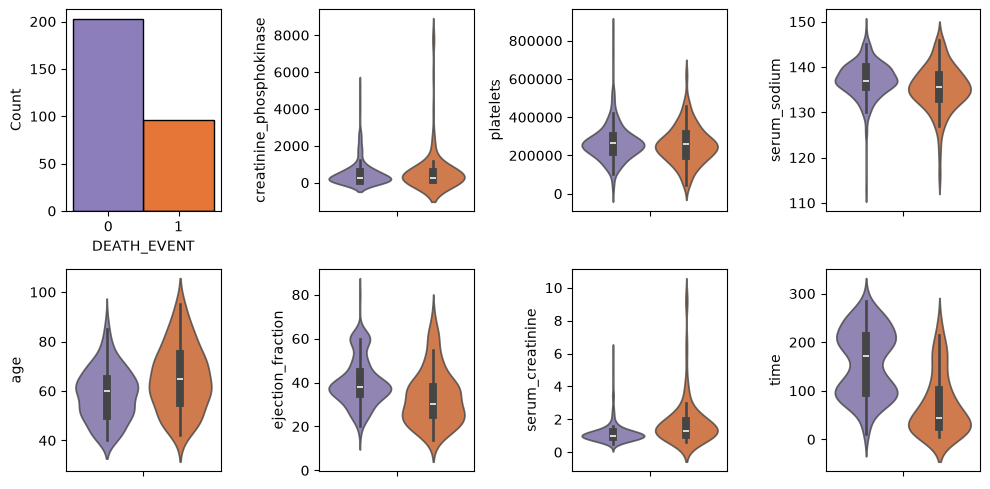

In [21]:
heartfail_colors = {0: "Purples", 1: "Oranges"}
heartfail_palette = seaborn.color_palette([seaborn.color_palette(heartfail_colors[0])[-2],
                                           seaborn.color_palette(heartfail_colors[1])[-2]])

f, axes = plt.subplots(2, (len(num_columns)+1)//2)
seaborn.histplot(data=heartfail_dtf, x=heartfail_targetname, hue=heartfail_targetname,
                 palette=heartfail_palette, discrete=True,
                 alpha=0.8, ax=axes[0, 0], legend=False)
for ci, c in enumerate(num_columns):
    seaborn.violinplot(heartfail_dtf, y=c, hue=heartfail_targetname,
                    ax=axes[(ci+1)%2, (ci+1)//2], width=0.95, dodge=True, gap=0.15,
                    palette=heartfail_palette, alpha=0.8, legend=False)
f.tight_layout()

About one third of the patients died during the follow-up period and two-third survived (`Count` histogram in the top, left-most panel). Overall, the patients who died seem to be slightly older (`age`), have lower ejection fraction (`ejection_fraction`), as well as somewhat lower serum sodium (`serum_sodium`) but higher serum creatinine (`serum creatinine`) values.

The follow-up time (`time`) is on average longer for patient who survived, which seems logical, since the death of a patient during the follow-up period causes it to end early.

Note that it would not make sense to use the follow-up time as predictive attribute when trying to predict whether patients survive.

Next, we focus on the six binary attributes, namely `DEATH_EVENT`, `sex`, `anaemia`, `high_blood_pressure` `diabetes` and `smoking`.

We count the number of times each of the $2^6=64$ different combinations of values for these attributes appears in the dataset, using our custom function `count_binary_values`.
We display these counts using heatmaps, considering separately patients who survived (purple, left-hand side) from patients who died (orange, right-hand side), and men (bottom) from women (top). The intensity of color of each cell is determined based on the fraction of patients from the considered subgroup that the cell represents within the corresponding population. The colormaps are scaled to the same range, to make the plots more easily comparable across the four different populations.

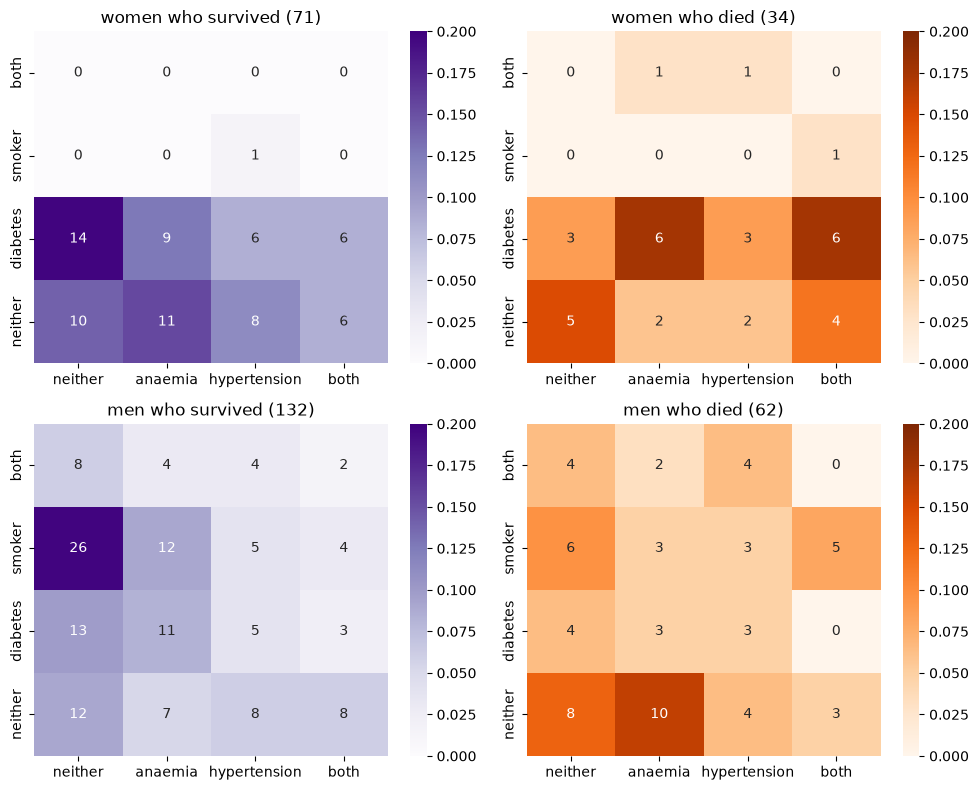

In [22]:
import itertools

def count_binary_values(dtf, binary_columns):
    cc = dtf.groupby(binary_columns).size()
    map_counts = dict([(k, 0) for k in itertools.product([0,1], repeat=len(binary_columns))])
    for i,v in enumerate(cc.values):
        map_counts[cc.index.values[i]] = v
    counts_array = numpy.array([k+(v,) for k,v in map_counts.items()])
    return pandas.DataFrame(counts_array, columns=cc.index.names + ["counts"])


heat_columns = ["high_blood_pressure", "anaemia"]
heat_column_labels = ["neither", "anaemia", "hypertension", "both"]
heat_rows = ["smoking", "diabetes"]
heat_row_labels = ["both", "smoker", "diabetes", "neither"]
varA = heartfail_targetname
varB = "sex"

counts_dtf = count_binary_values(heartfail_dtf, [varA, varB]+heat_columns+heat_rows)

subgroups = []
for valB in [0, 1]:
    for valA in [0, 1]:
        sub_counts = counts_dtf.loc[(counts_dtf[varA]==valA) & (counts_dtf[varB]==valB)]
        total = sub_counts["counts"].sum()
        counts_mat = sub_counts.pivot(index=heat_rows, columns=heat_columns, values="counts")\
            .sort_index(axis=0, ascending=False).sort_index(axis=1)
        subgroups.append({"valA": valA, "valB": valB,
                          "counts_mat": counts_mat,
                         "total": total,
                         "max_ratio": sub_counts["counts"].max()/total})

max_ratio = numpy.ceil(10*numpy.max([subg["max_ratio"] for subg in subgroups]))/10

f, axes = plt.subplots(2, 2)
for ci, subg in enumerate(subgroups):
    # heat_mat = 100*heat_mat
    seaborn.heatmap(subg["counts_mat"]/subg["total"], annot=subg["counts_mat"], fmt=".0f",
                    cmap=heartfail_colors[subg["valA"]], ax=axes[ci//2, ci%2], vmin=0, vmax=max_ratio)
    axes[ci//2, ci%2].set(xlabel="", ylabel="")
    axes[ci//2, ci%2].set_xticklabels(heat_column_labels)
    axes[ci//2, ci%2].set_yticklabels(heat_row_labels)
    axes[ci//2, ci%2].set_title("%s who %s (%d)" % ("women" if subg["valB"] == 0 else "men",
        "survived" if subg["valA"] == 0 else "died", subg["total"]))

f.set_figheight(8)
f.tight_layout()

We note that almost no female patients are smokers, as visible from the very low counts in the first two rows in the upper-most plots, whereas a large fraction of male patients smoke.

Many female patients who died had both diabetes and anaemia as well as possibly hypertension (6 patients each, dark brown cells in the top-right panel), whereas the conditions tend to be observed somewhat more often separately than in combination in female patients who survived.

No clear pattern of association between the conditions is visible.

Finally, we plot the distribution of age separately for patients who survived (purple) and patients who died (orange), further splitting successively by sex, smoking status, diabetes and hypertension.

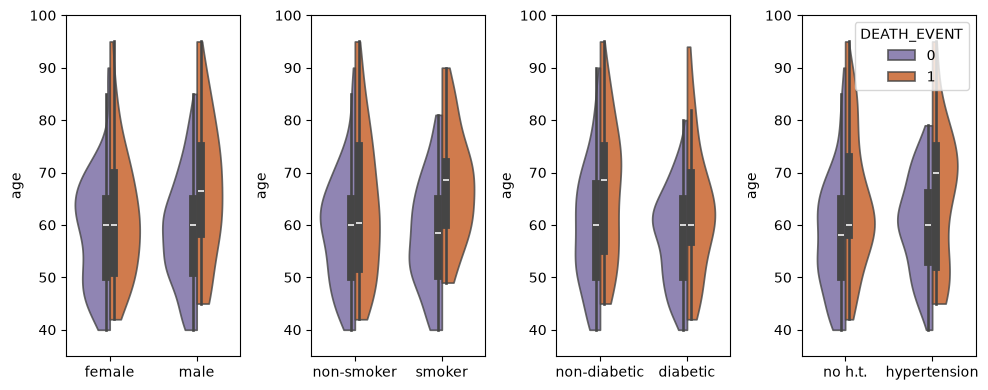

In [23]:
varsX = [("sex", ["female", "male"]), ("smoking", ["non-smoker", "smoker"]),
         ("diabetes", ["non-diabetic", "diabetic"]),("high_blood_pressure", ["no h.t.", "hypertension"])]

f, axes = plt.subplots(1, len(varsX))
for ci, (varX, lblsX) in enumerate(varsX):
    seaborn.violinplot(
        data=heartfail_dtf, x=varX, y="age", hue=heartfail_targetname, palette=heartfail_palette,
        alpha=0.8, cut=0, split=True, common_norm=True, ax=axes[ci], legend=ci==len(varsX)-1)
    axes[ci].set_xticks([0,1],lblsX)
    axes[ci].set_xlabel("")
    axes[ci].set_ylim(35,100)

f.set_figheight(4)
f.tight_layout()

While female patients in both outcome groups have the same median age, the median age of male patients who survived is about five years lower than the median age of male patients who died. Similarly, the median age of non-smoking patients is similar across both outcome groups, but the median age of smokers who survived is about ten years lower than that of smoking patients who died. On the other hand, the median age is similar for both outcome groups of diabetic patients, but almost ten years higher for non-diabetic patients who died than for non-diabetic patients who survived.

## *Maternal Health Risk* dataset

The [*Maternal Health Risk* dataset](https://archive.ics.uci.edu/dataset/863/maternal+health+risk) belongs to the area of health and medicine. It contains monitoring data of pregnant women collected mostly in a rural area of Bangladesh.
The classification task typically considered is to estimate the risk of maternal mortality.

The dataset contains six physiological attributes, namely the age (`Age`), upper and lower values of blood pressure (respectively `SystolicBP` and `DiastolicBP`), blood sugar concentration (`BS`), body temperature (`BodyTemp`) and heart rate (`HeartRate`), as well as a risk estimate (`RiskLevel`).

We load the data from the file and define variables for the original categorical target attribute, and for its numerical representation that we will use later on.

In [24]:
mhr_path = "./maternal+health+risk/Maternal Health Risk Data Set.csv"
mhr_dtf = pandas.read_csv(mhr_path, sep=",")
mhr_targetname = "RiskLevel"
mhr_numtargetname = "RiskNum"

We use our custom function to check whether there are any missing values.

In [25]:
check_missing_values(mhr_dtf)

No values are missing.


We show an outline of the dataset.

In [26]:
mhr_dtf

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk
...,...,...,...,...,...,...,...
1009,22,120,60,15.0,98.0,80,high risk
1010,55,120,90,18.0,98.0,60,high risk
1011,35,85,60,19.0,98.0,86,high risk
1012,43,120,90,18.0,98.0,70,high risk


All six physiological attributes take numerical values, while the risk level is represented using an ordinal attribute with three categories.

We create a new column encoding the risk level categories `low risk`, `mid risk` and `high risk` as numerical values `0`, `1` and `2`, respectively, so that the risk level are meaningfully ordered. We show their distribution as a histogram, using the Yellow-Orange-Brown (`YlOrBr`) color palette, such that the lower risk level is depicted in a lighter shade, yellow, whereas the higher risk level is depicted in a darker shade, brown.

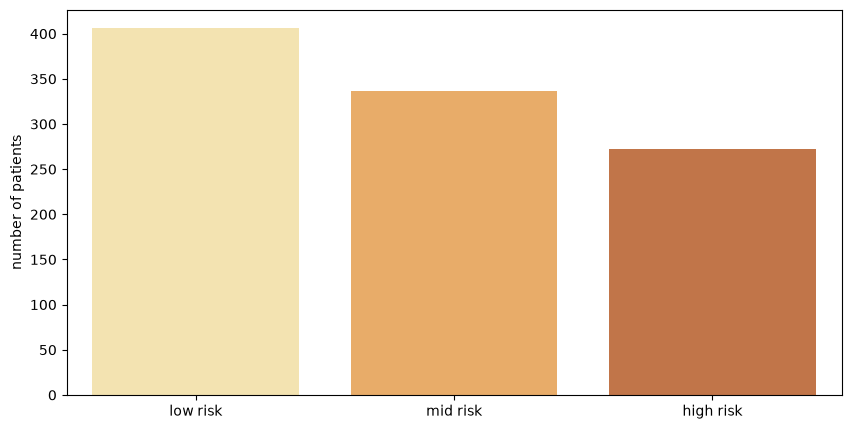

In [27]:
mhr_palette = seaborn.color_palette("YlOrBr", len(pandas.unique(mhr_dtf[mhr_targetname])))
mhr_dtf[mhr_numtargetname] = 0
mhr_dtf.loc[mhr_dtf[mhr_targetname]=="mid risk", mhr_numtargetname] = 1
mhr_dtf.loc[mhr_dtf[mhr_targetname]=="high risk", mhr_numtargetname] = 2

ax = seaborn.countplot(data=mhr_dtf, x=mhr_numtargetname, hue=mhr_numtargetname,
                 palette=mhr_palette, alpha=0.8, legend=None)
ax.set_xticks([0,1,2], ["low risk", "mid risk", "high risk"]);
ax.set_xlabel("");
ax.set_ylabel("number of patients");

We see that about forty percent of patients are evaluated as having a low health risk, whereas slightly more than a quarter are evaluated as having a high risk.

We show descriptive statistics, which by default include only numerical attributes.

The summary includes the number of distinct values (`count`, which is equal to the number of samples since no values are missing), the average value (`mean`), the standard deviation (`std`), the minimum and maximum values (`min` and `max`, respectively), as well as the 25th, 50th and 75th percentiles (`25%`, `50%` and `75%`, respectively).

In [28]:
mhr_dtf.describe()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskNum
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775,0.867850
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702,0.807353
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000,0.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000,0.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000,1.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000,2.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000,2.000000


The minimum value, 25th, 50th and 75th percentiles are all equal for the body temperature (`BodyTemp`), only the maximum value differs, representing an abnormally elevated value in a few patients.

Next, we compute and display correlations between pairs of attributes, sorting the attributes by decreasing correlation with the risk level, represented as a numerical value between 1 and 3.

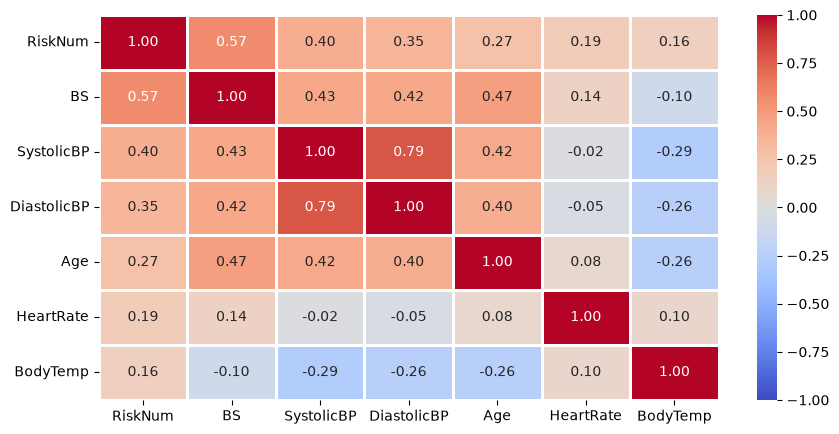

In [29]:
crm = mhr_dtf.corr(numeric_only=True)
sorted_columns = crm[mhr_numtargetname].sort_values(ascending=False).index
sorted_features = sorted_columns[1:]
seaborn.heatmap(crm.loc[sorted_columns,sorted_columns], linewidth=.8, vmin=-1, vmax=1,
                annot=True, fmt=".2f", cmap="coolwarm");

All physiological attributes are positively correlated with the numerical risk level. Since larger values of the numerical risk level indicate greater estimated health risk, this means that for all physiological attributes, higher values are associated with greater risk. This is more strongly the case for blood sugar concentration (`BS`), having a correlation of 0.57, whereas the correlation between risk level and heart rate and between risk level and body temperature are rather weak, both below twenty percent (0.19 and 0.16).

The two blood pressure attributes, `SystolicBP` and `DiastolicBP`, are quite strongly positively correlated (0.79). On the other hand, body temperature (`BodyTemp`) and age (`Age`) are negatively correlated, though not very strongly (-0.26), meaning that the few higher body temperatures have likely been recorded in younger patients.

We plot the distribution of each physiological attribute as a separate boxplot for each of the three risk groups.

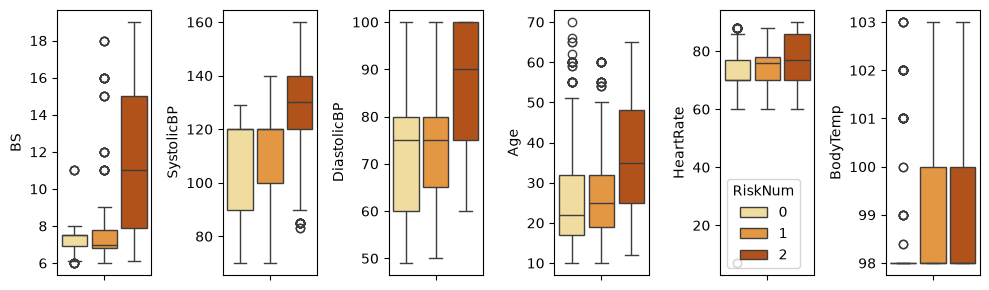

In [30]:
f, axes = plt.subplots(1, len(sorted_features))
for ci, c in enumerate(sorted_features):
    seaborn.boxplot(mhr_dtf, y=c, hue=mhr_numtargetname,
                    ax=axes[ci], width=0.95, dodge=True, gap=0.15,
                    palette=mhr_palette, legend=(ci==4))
f.set_figheight(3)
f.tight_layout()

The outlier value of seven beats per minutes observed as the heart rate for a patient in the low risk group is likely a measurement error.

## *National Poll on Healthy Aging (NPHA)* dataset

The [*National Poll on Healthy Aging (NPHA)* dataset](https://archive.ics.uci.edu/dataset/936/national+poll+on+healthy+aging+(npha)) provided on the *UCI* repository belongs to the area of health and medicine, containing features related to health and sleep in older American adults.

This is a subset of the original *National Poll on Healthy Aging (NPHA)* dataset, collected to study issues related to health and aging. A few variables were selected to use for a machine learning task aiming to predict the number of doctors a patient visits in a year.

For details about the dataset, the *UCI* webpage points to [the original NPHA study](https://www.icpsr.umich.edu/web/NACDA/studies/37305/versions/V1), on the *National Archive of Computerized Data on Aging (NACDA)*, hosted by the *Inter-university Consortium for Political and Social Research (ICPSR)*, a unit within the *Institute for Social Research* at the *University of Michigan*, USA.

We load the data from the file.

In [31]:
npha_path = "./national+poll+on+healthy+aging+(npha)/NPHA-doctor-visits.csv"
npha_orgdtf = pandas.read_csv(npha_path, sep=",")

We use our custom function to check whether there are any missing values.

In [32]:
check_missing_values(npha_orgdtf)

No values are missing.


We show an outline of the dataset.

In [33]:
npha_orgdtf

,Number of Doctors Visited,Age,Phyiscal Health,Mental Health,Dental Health,Employment,Stress Keeps Patient from Sleeping,Medication Keeps Patient from Sleeping,Pain Keeps Patient from Sleeping,Bathroom Needs Keeps Patient from Sleeping,Uknown Keeps Patient from Sleeping,Trouble Sleeping,Prescription Sleep Medication,Race,Gender
0,3,2,4,3,3,3,0,0,0,0,1,2,3,1,2
1,2,2,4,2,3,3,1,0,0,1,0,3,3,1,1
2,3,2,3,2,3,3,0,0,0,0,1,3,3,4,1
3,1,2,3,2,3,3,0,0,0,1,0,3,3,4,2
4,3,2,3,3,3,3,1,0,0,0,0,2,3,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
709,2,2,2,2,2,3,0,0,0,1,0,3,3,1,1
710,3,2,2,2,2,2,1,0,0,0,1,2,3,1,2
711,3,2,4,2,3,3,0,0,0,0,0,3,3,1,1
712,3,2,3,1,3,3,1,0,1,1,1,3,3,1,2


The dataset contains 714 rows, representing individual patients, and 15 columns, representing features related to health and sleep, as well as the number of doctors visited, which is the prediction target in the original task.

Each attribute contains only integer values. The meaning of the numerical values can be found on the [variables table on the *UCI* webpage](https://archive.ics.uci.edu/dataset/936/national+poll+on+healthy+aging+(npha)).


- **Number of Doctors Visited**: The total count of different doctors the patient has seen
    - **1**: 0&ndash;1 doctors
    - **2**: 2&ndash;3 doctors
    - **3**: 4 or more doctors
- **Age**: The patient's age group
    - **1**: 50&ndash;64 years old
    - **2**: 65&ndash;80 years old
- **Physical Health**: A self-assessment of the patient's physical well-being (Excellent&ndash;Poor)
- **Mental Health**: A self-evaluation of the patient's mental or psychological health (Excellent&ndash;Poor)
- **Dental Health**: A self-assessment of the patient's oral or dental health (Excellent&ndash;Poor)
- **Employment**: The patient's employment status or work-related information
	- **1**: Working full-time
	- **2**: Working part-time
	- **3**: Retired
	- **4**: Not working at this time
- **Stress Keeps Patient from Sleeping**: Whether stress affects the patient's ability to sleep (Yes/No)
- **Medication Keeps Patient from Sleeping**: Whether medication impacts the patient's sleep (Yes/No)
- **Pain Keeps Keeps Patient from Sleeping**: Whether physical pain disturbs the patient's sleep (Yes/No)
- **Bathroom Keeps Patient from Sleeping**: Whether the need to use the bathroom affects the patient's sleep (Yes/No)
- **Unknown Keeps Patient from Sleeping**: Unidentified factors affecting the patient's sleep (Yes/No)
- **Trouble Sleeping**: General issues or difficulties the patient faces with sleeping (Yes/No)
- **Prescription Sleep Medication**: Information about any sleep medication prescribed to the patient
	- **1**: Use regularly
	- **2**: Use occasionally
	- **3**: Do not use
- **Race**: The patient's racial or ethnic background
	- **1**: White, Non-Hispanic
	- **2**: Black, Non-Hispanic
	- **3**: Other, Non-Hispanic
	- **4**: Hispanic
	- **5**: 2+ Races, Non-Hispanic
- **Gender**: The gender identity of the patient
	- **1**: Male
	- **2**: Female

Throughout, values equal to **-1** indicate that the patient refused to answer.

Attributes corresponding to Yes/No questions use the following encoding of the answers:
- **0**: No
- **1**: Yes

Health self-assessment attributes are measured on a five steps scale, from excellent to poor, as follows:
- **1**: Excellent
- **2**: Very Good
- **3**: Good
- **4**: Fair
- **5**: Poor

We obtain a summary of the dataset, considering the attributes as discrete variables to get count statistics rather than distributional statistics.
That is, for each attribute the summary includes the number of values (`count`, which is equal to the number of samples since no values are missing), the number of distinct values (`unique`), the most frequent value and its number of occurrences (`top` and `freq`, respectively).

In [34]:
npha_orgdtf.astype(object).describe()

,Number of Doctors Visited,Age,Phyiscal Health,Mental Health,Dental Health,Employment,Stress Keeps Patient from Sleeping,Medication Keeps Patient from Sleeping,Pain Keeps Patient from Sleeping,Bathroom Needs Keeps Patient from Sleeping,Uknown Keeps Patient from Sleeping,Trouble Sleeping,Prescription Sleep Medication,Race,Gender
count,714,714,714,714,714,714,714,714,714,714,714,714,714,714,714
unique,3,1,6,6,7,4,2,2,2,2,2,4,4,5,2
top,2,2,3,2,2,3,0,0,0,1,0,3,3,1,2
freq,372,714,291,282,215,592,537,674,558,360,416,359,639,578,393


We note that all values of the `Age` attribute are equal to 2 (corresponding to the age range of 65 to 80 years old), making it useless, so we drop this attribute.
We also note a couple of typos in the names of attributes, which we correct, and we abbreviate the phrase `Keeps Patient from Sleeping` to `KPfS`.

In [35]:
npha_dtf = npha_orgdtf.drop(columns="Age").rename(columns=
                    lambda x: x.replace("Phyiscal", "Physical").replace("Uknown", "Unknown").replace("Keeps Patient from Sleeping", "KPfS"))

Furthermore, we note that while `Trouble Sleeping` is listed as a Yes/No variable in the [variables table on the UCI webpage](https://archive.ics.uci.edu/dataset/936/national+poll+on+healthy+aging+(npha)), the attribute contains four distinct values, namely values -1, 1, 2 and 3. From the [description of variables in the original dataset](https://www.icpsr.umich.edu/web/NACDA/studies/37305/versions/V1/variables?q=trouble), and in particular [variable `PROB_FALLING_ASLEEP`](https://www.icpsr.umich.edu/web/NACDA/studies/37305/datasets/0001/variables/PROB_FALLING_ASLEEP?archive=nacda), it seems probable that the attribute records the frequency at which patients face trouble falling asleep (presumably on a weekly basis), with values 1, 2 and 3 encoding respectively 3&ndash;7 nights, 1&ndash;2 nights, and 0 nights.

Also, while we expect health self-assessment attributes to be measured on a five steps scale, and hence to take six distinct values when including the option representing a refusal to answer, we observe that `Dental Health` actually comes with seven distinct values, including an unexpected value 6, as we will see shortly. As a result, it is not clear how to interpret the values of this attribute.

Next, we draw histograms of the different attributes.
On the first row, we display the attributes recording whether medication, pain, stress, bathroom visits and unknown factors affect patients' ability to sleep.
On the second row, we display the physical, mental and dental health self-evaluation scores, as well as a score recording the level of trouble sleeping and the original target attribute recording the number of doctors visited.
On the last row, we display demographic attributes, recording respectively the gender, race and employment status of the patients, as well the attribute recording the use of prescribed sleep medication.

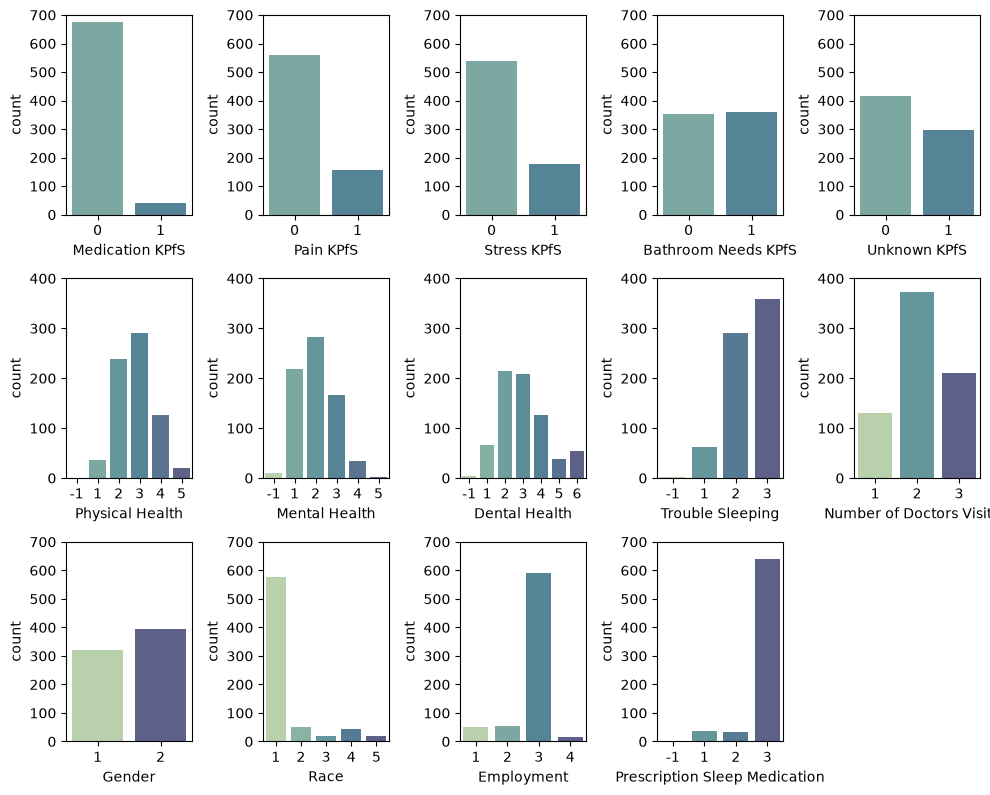

In [36]:
sorted_columns = ["Medication KPfS", "Pain KPfS", "Stress KPfS", "Bathroom Needs KPfS", "Unknown KPfS",
                  "Physical Health", "Mental Health", "Dental Health", "Trouble Sleeping", "Number of Doctors Visited",
                  "Gender", "Race", "Employment", "Prescription Sleep Medication"]
f, axes = plt.subplots(3, 5)
for ci, c in enumerate(sorted_columns):
    seaborn.countplot(data=npha_dtf, x=c, alpha=0.8, legend=None, ax=axes[ci//5, ci%5], hue=c, palette="crest")
    axes[ci//5, ci%5].set_ylim([0,400 if ci//5 ==1 else 700])
axes[-1, -1].axis("off")

f.set_figheight(8)
f.tight_layout()

The need to use the bathroom is the most common factor affecting patients' ability to sleep, with slightly more than half of the patients reporting it. Unsurprisingly considering the age group, most patients are retired (`Employment` value 3). Most patients do not use sleep medication (`Prescription Sleep Medication` value 3).

Next, we compute and display correlations between pairs of attributes, keeping the attributes in the same order as in the previous figure.
We show only the lower triangle of the correlation matrix, which is enough to visualize all the information, since the upper triangle is identical to it under symmetry along the diagonal, and display values as signed percentages.

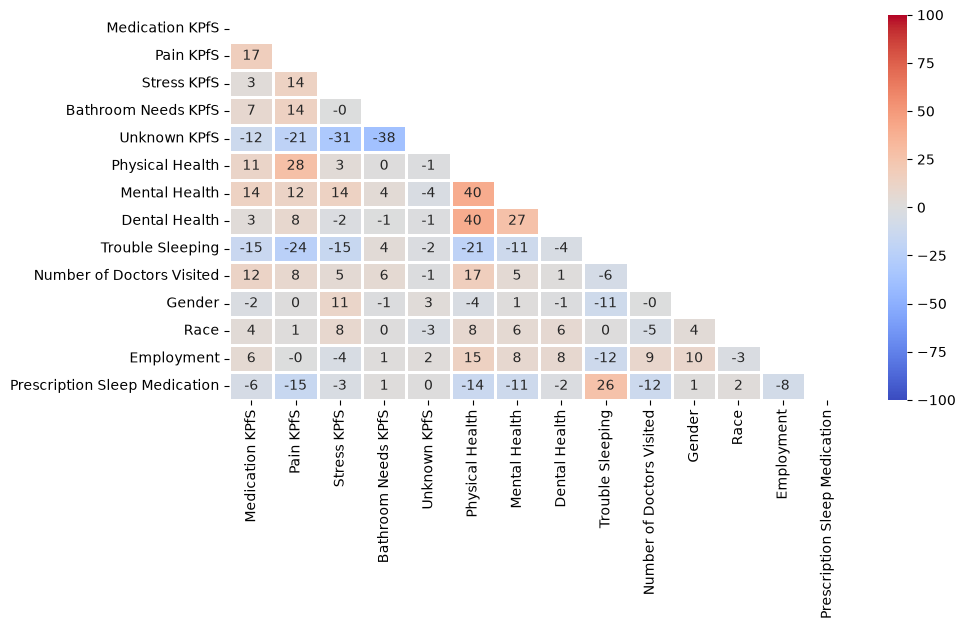

In [37]:
crm = 100*npha_dtf.corr().loc[sorted_columns,sorted_columns]
mask = numpy.triu(numpy.ones_like(crm, dtype=bool))
seaborn.heatmap(crm, linewidth=.8, vmin=-100, vmax=100, mask=mask,
                annot=True, fmt=".0f", cmap="coolwarm");

Whereas known factors keeping patients from sleeping are weakly positively correlated with each other, the attribute representing unknown factors is more strongly negatively correlated with known factors. This seems fairly logical. If a patient declares some known factor as affecting their ability to sleep, they are less likely to also declare unknown factors.

Health self-evaluation scores are positively correlated with each other, meaning that the different aspects of health are not independent.
Finally, the `Trouble Sleeping` attribute is negatively correlated with most factors affecting sleep. That is, lower values for this attribute, representing more frequent troubles, tend to be associated with declaring some factors causing the troubles, especially pain (-24%), followed by medication (-15%) and stress (-15%). On the other hand, there is almost no correlation between the need to use the bathroom as factor affecting sleep and frequent troubles falling asleep (-2%).

## *Students' Dropout* dataset

The [*Students' Dropout*](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success) dataset belongs to the area of learning analytics. It contains information about the demographics and socioeconomic background, as well as the academic path and performance of students enrolled in different undergraduate degrees at an institution of higher education in Portugal. The task typically considered is to predict students' academic performance, so as to detect students at risk of failure.

For details about the dataset, the *UCI* webpage points to
- Martins, M.V., Tolledo, D., Machado, J., Baptista, L.M.T., Realinho, V. (2021). *Early Prediction of student’s Performance in Higher Education: A Case Study.* In:  Trends and Applications in Information Systems and Technologies (WorldCIST 2021). Advances in Intelligent Systems and Computing, vol 1365. Springer. https://doi.org/10.1007/978-3-030-72657-7_16

We load the data from the file and create a variable containing the name of the prediction target.

In [38]:
dropout_path = "./predict+students+dropout+and+academic+success/data.csv"
dropout_dtf = pandas.read_csv(dropout_path, sep=";")
dropout_targetname = "Target"

We use our custom function to check whether there are any missing values.

In [39]:
check_missing_values(dropout_dtf)

No values are missing.


We show an outline of the dataset.

In [40]:
dropout_dtf

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


The dataset contains 4424 rows representing enrolled students.
The last attribute, **Target**, represents students performance as a categorical attribute with three different values, namely **Enrolled**, **Dropout** and **Graduate**.

The other thirty-six attributes take numerical values.

Twelve of them represent actual quantities or orderings:
- **Age at enrollment**
- **Application order**, between 0 (first choice) and 9 (last choice)
- **Previous qualification (grade)**, between 0 and 200
- **Admission grade**, between 0 and 200
- **Curricular units 1st sem (credited)** and **Curricular units 2nd sem (credited)**, the number of curricular units credited in the 1st and 2nd semesters, respectively
- **Curricular units 1st sem (enrolled)** and **Curricular units 2nd sem (enrolled)**, the number of curricular units enrolled in the 1st and 2nd semesters, respectively
- **Curricular units 1st sem (evaluations)** and **Curricular units 2nd sem (evaluations)**, the number of evaluations to curricular units in the 1st and 2nd semesters, respectively
- **Curricular units 1st sem (approved)** and **Curricular units 2nd sem (approved)**, the number of curricular units approved in the 1st and 2nd semesters, respectively

Some represent answers to yes/no questions, where values 1 and 0 represent respectively 'yes' and 'no', namely:
- **Displaced**
- **Educational special needs**
- **Debtor**
- **Tuition fees up to date**
- **Scholarship holder**
- **International**

**Gender** and **Daytime/evening attendance** are additional binary attributes, with values 0 and 1 representing respectively **female** and **male**, on one hand, **evening** and **daytime**, on the other hand.

The meaning of the numerical values for the other attributes can be found on the [variables table on the *UCI* webpage](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success).

We drop the stray tab character from the end of an attribute name.

In [41]:
dropout_dtf.rename(columns={"Daytime/evening attendance\t": "Daytime/evening attendance"}, inplace=True)

We draw a histogram of the students performance per course.

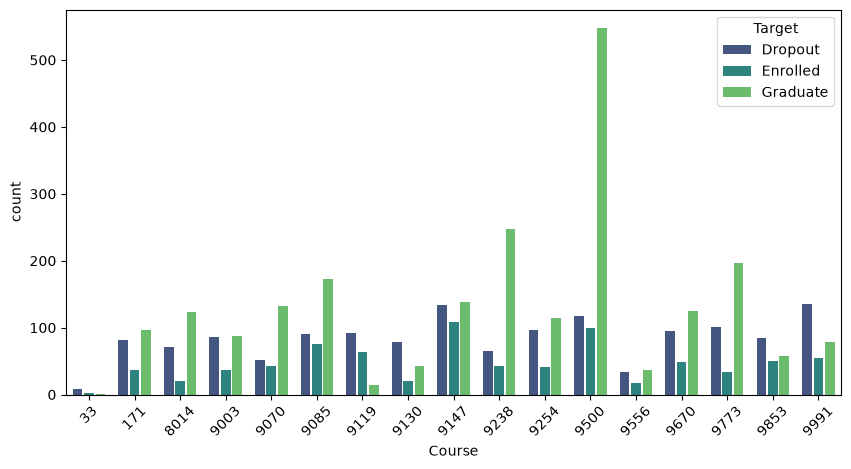

In [42]:
dropout_palette = seaborn.color_palette("viridis", 3)
ax= seaborn.countplot(x=dropout_dtf["Course"], hue=dropout_dtf[dropout_targetname],
                    palette=dropout_palette, width=0.75, dodge=True, gap=0.15)
ax.tick_params("x", rotation=45)

The course names are as follows:
- **33**: Biofuel Production Technologies
- **171**: Animation and Multimedia Design
- **8014**: Social Service (evening attendance)
- **9003**: Agronomy
- **9070**: Communication Design
- **9085**: Veterinary Nursing
- **9119**: Informatics Engineering
- **9130**: Equinculture
- **9147**: Management
- **9238**: Social Service
- **9254**: Tourism
- **9500**: Nursing
- **9556**: Oral Hygiene
- **9670**: Advertising and Marketing Management
- **9773**: Journalism and Communication
- **9853**: Basic Education
- **9991**: Management (evening attendance)

*Nursing (9500)* and *Social service (9238)* are the two courses with the largest number of graduates, both have a small proportion of dropouts compared to graduates. On the other hand, *Informatics Engineering (9119)* has very few graduates and about as many dropouts as graduates and enrolled combined.

Since several attributes have a large number of distinct values, few of which appear frequently in the data, we write a function to select a subset of representative values for a given attribute.

In [43]:
def representative_values(s, rfrac):
    """Select the most frequent values that together represent a fraction `rfrac` (float) of the occurrences in `s` (pandas.Series).
    Returns
        - A copy of the input series where occurrences of representative values are replaced by their position in the selection,
            and occurrences of other values are replaced by `nan`
        - The ordered list of representative values. The last entry is `nan` if some values were not selected as representative
        - The occurrence counts of the values
        - The total number of representative values
    """
    cv = s.value_counts().sort_values(ascending=False)
    tot = len(s)
    nb = (cv.cumsum()/tot < rfrac).sum()+1
    keep_cv = cv.iloc[:nb + 1 if nb + 1 == len(cv) else nb].sort_index()
    values, counts = map(list, zip(*keep_cv.items()))
    s_rep = s.copy()
    if len(keep_cv) < len(cv):
        mask_nan = ~s_rep.isin(values)
        counts.append(mask_nan.sum())
        s_rep.loc[mask_nan] = numpy.nan
        values.append(numpy.nan)
    map_vs = dict([(v, i) for (i, v) in enumerate(values)])
    return s_rep.map(map_vs), values, counts, nb

We use this function to draw histograms showing the distribution of the representative values across the three performance categories for attributes with several representative values.

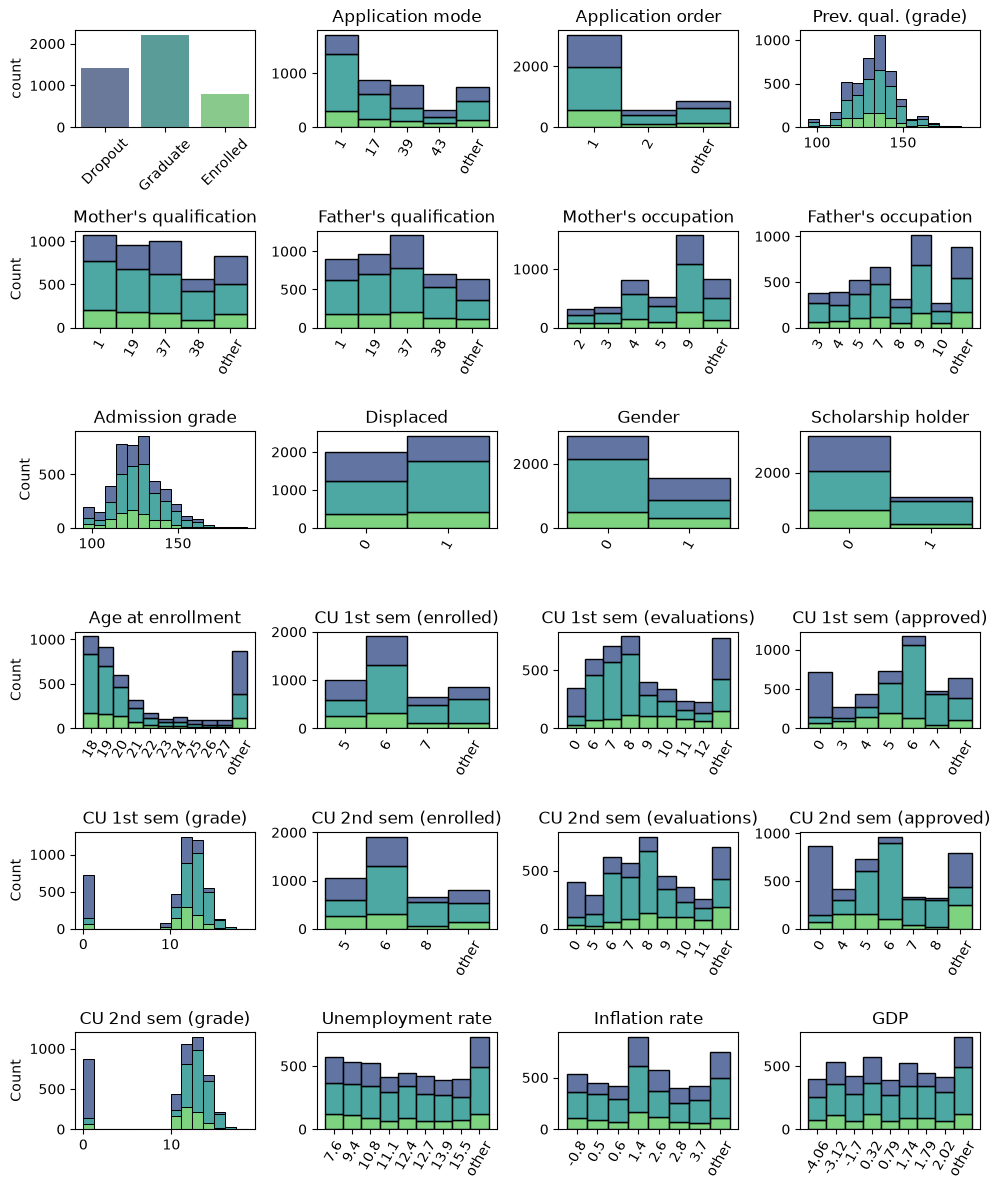

In [44]:
per_row = 4
f, axes = plt.subplots(6, per_row)
ci = 0
seaborn.countplot(x=dropout_dtf[dropout_targetname], hue=dropout_dtf[dropout_targetname],
                    ax=axes[ci//per_row, ci%per_row],
                    palette=dropout_palette, legend=False, alpha=0.8, linewidth=1)
axes[ci//per_row, ci%per_row].set_xlabel("")
axes[ci//per_row, ci%per_row].tick_params("x", rotation=45)
for cid, cname in enumerate(dropout_dtf.columns):
    v_rep, vs, cs, nb = representative_values(dropout_dtf[cname], 0.8)
    if nb <= 1 or cname in [dropout_targetname, "Course"]:
        continue

    ci += 1
    if nb <= 15: # attributes with a few representative values
        seaborn.histplot(x=v_rep, hue=dropout_dtf[dropout_targetname],
                    ax=axes[ci//per_row, ci%per_row], multiple="stack",
                    palette=dropout_palette, discrete=True, legend=False, alpha=0.8)
        if numpy.isnan(vs[-1]):
            vs[-1] = "other"
        axes[ci//per_row, ci%per_row].set_xticks(range(len(vs)), vs,rotation=60)
    else: # attributes with a large number of representative values, actual numerical attributes
        seaborn.histplot(x=dropout_dtf[cname], hue=dropout_dtf[dropout_targetname], bins=15,
                    ax=axes[ci//per_row, ci%per_row], multiple="stack",
                    palette=dropout_palette, legend=False, alpha=0.8)
    if ci%per_row > 0:
        axes[ci//per_row, ci%per_row].set_ylabel("")
    axes[ci//per_row, ci%per_row].set_xlabel("")
    axes[ci//per_row, ci%per_row].set_title(cname\
                                             .replace("Curricular units", "CU")\
                                             .replace("Previous qualification", "Prev. qual."))
f.set_figheight(12)
f.tight_layout()

We provide clarifications for the values of attributes appearing in the histograms.

- **Application mode**:
	- **1**: 1st phase - general contingent
	- **17**: 2nd phase - general contingent
	- **39**: Over 23 years old
	- **43**: Change of course
- **Mother's qualification** and **Father's qualification**: Education Level
	- **1**: Secondary Education - 12th Year of Schooling or Equiv.
	- **19**: Basic Education 3rd Cycle (9th/10th/11th Year) or Equiv.
	- **37**: Basic education 1st cycle (4th/5th year) or Equiv.
	- **38**: Basic Education 2nd Cycle (6th/7th/8th Year) or Equiv.
- **Mother's occupation** and **Father's occupation**:
	- **2**: Specialists in Intellectual and Scientific Activities
	- **3**: Intermediate Level Technicians and Professions
	- **4**: Administrative staff
	- **5**: Personal Services, Security and Safety Workers and Sellers
	- **6**: Farmers and Skilled Workers in Agriculture, Fisheries and Forestry
	- **7**: Skilled Workers in Industry, Construction and Craftsmen
	- **8**: Installation and Machine Operators and Assembly Workers
	- **9**: Unskilled Workers
	- **10**: Armed Forces Professions

We note that dropouts are over-represented among students who enrolled at age 23 and over (`Application mode` value 39 and left-most bars in `Age at enrollment`).
On the other hand, the proportion of graduates is much higher among female students (`Gender` value 0) than among male students, and even more so among scholarship holders (`Scholarship` value 1) than among students who do not receive a scholarship. It is also higher among students who enrolled in and got approved more curricular units than average (`CU 1st/2nd sem (enrolled/approved)`), received above average grades (`CU 1st/2nd sem (grade)`), and who took evaluations for between 6 and 8 curricular units (`CU 1st/2nd sem (evaluations)`)

## *Student Performance* dataset

The [*Student Performance* dataset](https://archive.ics.uci.edu/dataset/320/student+performance) belongs to the area of learning analytics, containing demographic and social background as well as grades of students from two secondary schools in Portugal. It consists of two tables corresponding to two different topics, namely mathematics and Portuguese language.

For details about the dataset, the *UCI* webpage points to
- Cortez P., Silva A. M. G. (2008). *Using data mining to predict secondary school student performance* In: Proceedings of 5th Annual Future Business Technology Conference

The grades for the first and second periods are provided, as well as a the final grade. The task typically considered is to predict the final grades. Because the final grade is strongly correlated with the first and second period grades, it is easier to predict it with the intermediate grades, but of limited interest.

We load the two data tables from the respective files, first the Portuguese language (por) then the mathematics (mat).

In [45]:
spp_path = "./student+performance/student-por.csv"
spp_dtf = pandas.read_csv(spp_path, sep=";")
spp_dtf

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,MS,F,19,R,GT3,T,2,3,services,other,...,5,4,2,1,2,5,4,10,11,10
645,MS,F,18,U,LE3,T,3,1,teacher,services,...,4,3,4,1,1,1,4,15,15,16
646,MS,F,18,U,GT3,T,1,1,other,other,...,1,1,1,1,1,5,6,11,12,9
647,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,6,10,10,10


In [46]:
spm_path = "./student+performance/student-mat.csv"
spm_dtf = pandas.read_csv(spm_path, sep=";")
spm_dtf

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10


Both tables contain the same thirty-four columns. The Portuguese language table contains 649 rows, whereas the mathematics table contains only 395 rows. In both cases each row represents a student.

According to the additional information provided at the end of the list of attributes, several students (382, to be specific) appear in both tables and they can be identified by looking for matching values across the tables when considering a subset of identifying attributes. An example *R* script is provided for doing the matching, from which we can see that the subset of identifying attributes considered is consists of
 `school`,`sex`,`age`,`address`,`famsize`,`Pstatus`,`Medu`,`Fedu`,`Mjob`,`Fjob`,`reason`,`nursery` and`internet`.

Accordingly, we will try to merge the two tables. First, we create a column in each table to store the respective original row indices, allowing us to easily identify which rows in the separate tables a row in the merged table corresponds to.

In [47]:
spm_dtf["index"] = spm_dtf.index
spp_dtf["index"] = spp_dtf.index

Next, we split the attributes into attributes used in the provided script for merging (`columns_merge`), attributes that are topic-specific (`columns_specific`), and other attributes (`columns_more`).

In [48]:
columns_merge = ["school","sex","age","address","famsize","Pstatus","Medu","Fedu","Mjob","Fjob",
                 "reason","nursery","internet"]
columns_specific = ["index", "failures", "paid", "absences", "G1", "G2", "G3"]
columns_more = [c for c in spm_dtf.columns if c not in columns_merge+columns_specific]

Then, we merge the tables on the chosen attributes. We do an *inner* merge, meaning that we will only keep records that appear in both tables, and we add suffixes to the rest of attributes, not used for matching.

In [49]:
spmerge_dtf = pandas.merge(spm_dtf, spp_dtf, on=columns_merge, how="inner", suffixes=("_mat", "_por"))
spmerge_dtf

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime_por,goout_por,Dalc_por,Walc_por,health_por,absences_por,G1_por,G2_por,G3_por,index_por
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,4,0,11,11,0
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,2,9,11,11,1
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,6,12,13,12,2
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,0,14,14,14,3
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,0,11,13,13,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377,MS,F,18,U,LE3,T,3,1,teacher,services,...,3,4,1,1,1,4,15,15,16,645
378,MS,F,18,U,GT3,T,1,1,other,other,...,4,4,2,2,5,3,7,8,7,590
379,MS,F,18,U,GT3,T,1,1,other,other,...,1,1,1,1,5,6,11,12,9,646
380,MS,M,17,U,LE3,T,3,1,services,services,...,4,5,3,4,2,6,10,10,10,647


The merger results in a table with 832 rows, in agreement with the statement that 382 students appear in both tables.

However, we check whether any indices from the separate tables have been duplicated in the merged table, which would indicate that the merger is not a one-to-one correspondence.

In [50]:
spmerge_dtf.loc[spmerge_dtf["index_mat"].duplicated(keep=False) | spmerge_dtf["index_por"].duplicated(keep=False),
    ["index_mat", "index_por"]]

,index_mat,index_por
78,78,78
79,78,155
108,107,107
109,107,195
117,115,115
118,115,161
146,144,78
147,144,155
151,148,115
152,148,161


We see that indeed some students from one table have been matched to two distinct students in the other table, which clearly cannot be correct.

We attempt to merge again, but this time using all attributes that are not topic-specific.

In [51]:
spmandp_dtf = pandas.merge(spm_dtf, spp_dtf, on=columns_merge+columns_more, how="inner", suffixes=("_mat", "_por"))
spmandp_dtf

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,G2_mat,G3_mat,index_mat,failures_por,paid_por,absences_por,G1_por,G2_por,G3_por,index_por
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,6,6,0,0,no,4,0,11,11,0
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,6,1,0,no,2,9,11,11,1
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,8,10,2,0,no,6,12,13,12,2
3,GP,F,15,U,GT3,T,4,2,health,services,...,14,15,3,0,no,0,14,14,14,3
4,GP,F,16,U,GT3,T,3,3,other,other,...,10,10,4,0,no,0,11,13,13,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
365,MS,F,19,R,GT3,T,2,3,services,other,...,5,0,387,1,no,4,10,11,10,644
366,MS,F,18,U,LE3,T,3,1,teacher,services,...,9,8,388,0,no,4,15,15,16,645
367,MS,F,18,U,GT3,T,1,1,other,other,...,5,0,389,0,no,6,11,12,9,646
368,MS,M,17,U,LE3,T,3,1,services,services,...,16,16,391,0,no,6,10,10,10,647


We obtain a table that contains twelve rows fewer, with 370 rows instead of 382.

We check whether we have any duplicate indices from the separate tables.

In [52]:
spmandp_dtf.loc[spmandp_dtf["index_mat"].duplicated(keep=False) | spmandp_dtf["index_por"].duplicated(keep=False),
    ["index_mat", "index_por"]]

,index_mat,index_por


Indeed, there are none, so the merger on the larger set of columns is a one-to-one correspondence.

Further, we check some properties of the matched indices from the separate tables, under the two merging strategies.

In [53]:
for (topic, suff) in [("mathematics", "_mat"), ("Portuguese language", "_por")]:
    diffA = set(spmerge_dtf["index"+suff].values).difference(spmandp_dtf["index"+suff].values)
    diffB = set(spmandp_dtf["index"+suff].values).difference(spmerge_dtf["index"+suff].values)
    if len(diffA) + len(diffB) == 0:
        print(f"The row indices from the {topic} table appearing in the merged table are the same for both merging strategies.")
    else:
        for (whichX, diffX) in [("on the columns from the provided script", diffA),
                           ("on the larger set of columns", diffB)]:
            if len(diffX) > 0:
                s  = f"Some row indices from the {topic} table"
                s += f" appear in the merged table only when merged {whichX}"
                s += " (namely %s)." % ", ".join(["%d" % v for v in diffX])
                print(s)

print(("When merged on the columns from the provided script,\n" + \
      " there are %d and %d unique row indices from the Portuguese language and mathematics tables, respectively,\n" +\
      " with %d and %d non-increasing successive values.") % (
      len(set(spmerge_dtf["index_por"].values)), len(set(spmerge_dtf["index_mat"].values)),
      (numpy.diff(spmerge_dtf["index_por"].values) <= 0).sum(), (numpy.diff(spmerge_dtf["index_mat"].values) <= 0).sum()
      ))

print(("When merged on the larger set of columns,\n" + \
      " there are %d and %d unique row indices from the Portuguese language and mathematics tables, respectively,\n" +\
      " with %d and %d non-increasing successive values.") % (
      len(set(spmandp_dtf["index_por"].values)), len(set(spmandp_dtf["index_mat"].values)),
      (numpy.diff(spmandp_dtf["index_por"].values) <= 0).sum(), (numpy.diff(spmandp_dtf["index_mat"].values) <= 0).sum()
      ))

The row indices from the mathematics table appearing in the merged table are the same for both merging strategies.
Some row indices from the Portuguese language table appear in the merged table only when merged on the columns from the provided script (namely 590, 271, 151, 376).
When merged on the columns from the provided script,
 there are 374 and 370 unique row indices from the Portuguese language and mathematics tables, respectively,
 with 12 and 12 non-increasing successive values.
When merged on the larger set of columns,
 there are 370 and 370 unique row indices from the Portuguese language and mathematics tables, respectively,
 with 0 and 0 non-increasing successive values.


Observing
- that the same 370 row indices from the smaller table (mathematics), are matched with the two strategies,
- that four extra row indices from the larger table (Portuguese language) are matched when using only the columns specified in the provided script, and
- that successive matched row indices are strictly increasing when using the larger set of columns,

increases our confidence that this merging strategy is correct.

Finally, we show how the previously duplicated row indices are matched in the one-to-one correspondence.

In [54]:
spmandp_dtf.loc[spmandp_dtf["index_mat"].isin(spmerge_dtf.loc[spmerge_dtf["index_mat"].duplicated(), "index_mat"].values),
    ["index_mat", "index_por"]]

,index_mat,index_por
78,78,78
107,107,107
115,115,115
143,144,155
147,148,161
176,181,195
238,243,270
272,277,319
278,283,328
312,328,380


We see that indeed the row indices in each of the three lists grow monotonically. Row indices from the mathematics table are equal to the row indices in the merged table or larger by small values, whereas row indices from the Portuguese language table are larger still. This means that only a few students from the mathematics table are skipped during matching, as they do not appear in the other table, whereas many more students from the Portuguese language table are skipped. This is expected given that the Portuguese language table is much larger than the mathematics table.

We create an attribute `G3_avg` to record the average final grade.

In [55]:
spmandp_dtf["G3_avg"] = spmandp_dtf[["G3_mat", "G3_por"]].mean(axis=1)

We display the matrix of correlations between pairs of attributes recording grades, absences or failures.

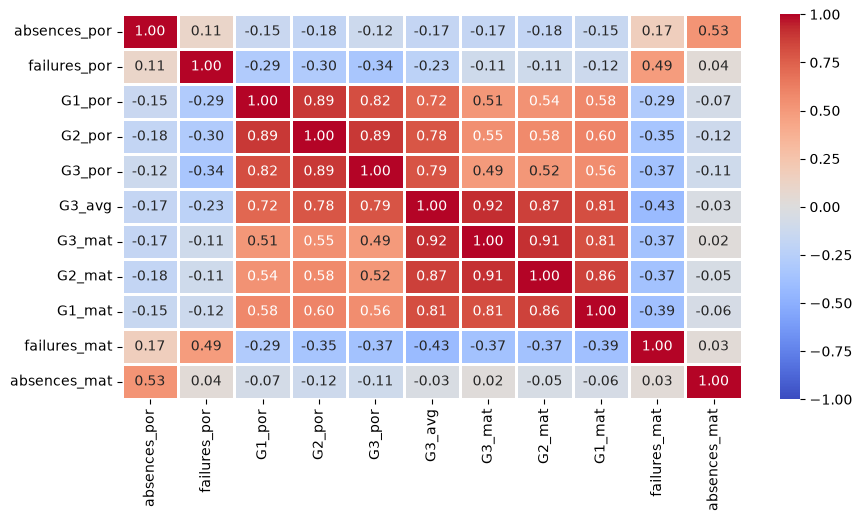

In [56]:
columns_corr = ["absences_por", "failures_por",
                "G1_por", "G2_por", "G3_por",
                "G3_avg",
                "G3_mat", "G2_mat", "G1_mat",
                "failures_mat", "absences_mat"]
crm = spmandp_dtf[columns_corr].corr()
seaborn.heatmap(crm, linewidth=.8, vmin=-1, vmax=1, annot=True, fmt=".2f", cmap="coolwarm");

The grades are all strongly positively correlated within a topic (correlations above 0.80) and less strongly across the topics (correlations in the range 0.49&mdash;0.60).
Failures are somewhat negatively correlated with grades in the corresponding topic (correlations -0.29, -0.30 and -0.34 for Portuguese language and -0.37, -0.37 and -0.39 for mathematics), indicating that, expectedly, lower grades in a topic are associated with more failures in it. Somewhat surprisingly, failures in mathematics are slightly more strongly negatively correlated with grades in Portuguese language (correlations -0.29, -0.35 and -0.37), than failures in that topic.
Absences are hardly correlated with grades, but quite strongly positively correlated across topics (0.53 correlation).

We draw scatter plots of students grades, in two columns, the left-hand side for the Portuguese language course and the right-hand side for the mathematics courses.

On the first row, we plot the grades for the first period (horizontal axis) against the grades for the second period (vertical axis) with the size and color of the circles depicting the final grade.
On the second and third rows, we plot the final grades (horizontal axis) against the grades for the first period and the second period (vertical axis), respectively, with the size and color of the circles depicting the final grade for the other topic.

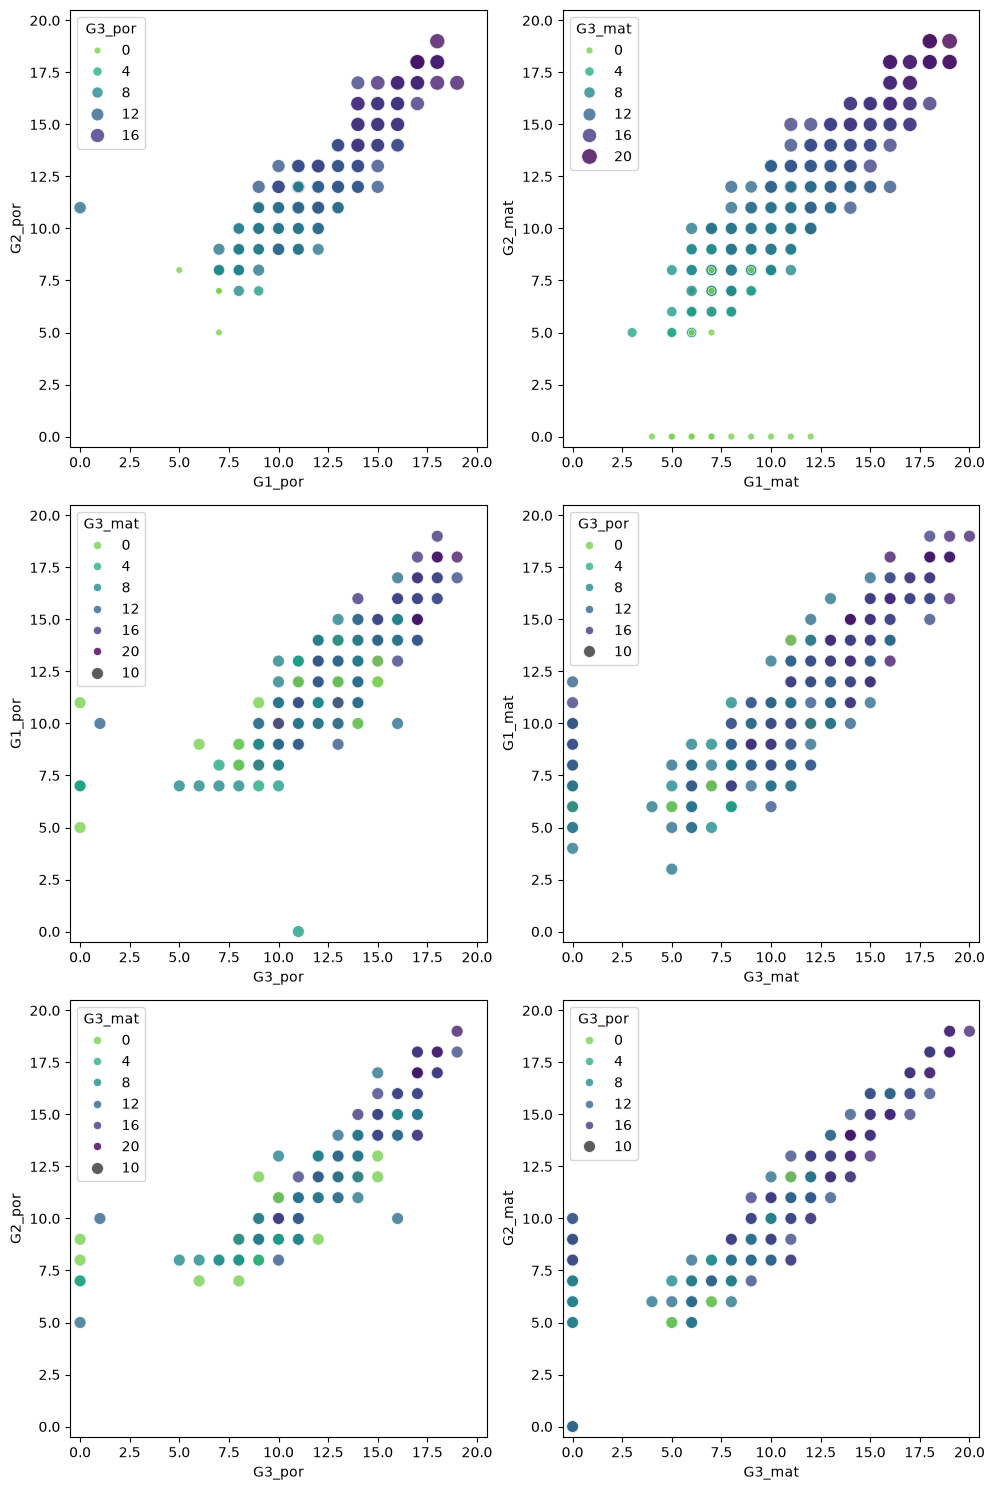

In [57]:
f, axes = plt.subplots(3, 2)
suffixes = ["_por", "_mat"]
palette_grade = "viridis_r"
for i, suff in enumerate(suffixes):

    seaborn.scatterplot(x=spmandp_dtf[f"G1{suff}"], y=spmandp_dtf[f"G2{suff}"],
                        size=spmandp_dtf[f"G3{suff}"], size_norm=(0, 20), sizes=(25, 125),
                        hue=spmandp_dtf[f"G3{suff}"], hue_norm=(-5,20), palette=palette_grade, alpha=0.8,
                        ax=axes[0,i])
    axes[0,i].set_xlim([-.5,20.5])
    axes[0,i].set_ylim([-.5,20.5])

    seaborn.scatterplot(x=spmandp_dtf[f"G3{suff}"], y=spmandp_dtf[f"G1{suff}"],
                        size=10, size_norm=(0, 20), sizes=(25, 125),
                        hue=spmandp_dtf[f"G3{suffixes[1-i]}"], hue_norm=(-5,20), palette=palette_grade, alpha=0.8,
                        ax=axes[1,i])
    axes[1,i].set_xlim([-.5,20.5])
    axes[1,i].set_ylim([-.5,20.5])

    seaborn.scatterplot(x=spmandp_dtf[f"G3{suff}"], y=spmandp_dtf[f"G2{suff}"],
                        size=10, size_norm=(0, 20), sizes=(25, 125),
                        hue=spmandp_dtf[f"G3{suffixes[1-i]}"], hue_norm=(-5,20), palette=palette_grade, alpha=0.8,
                        ax=axes[2,i])
    axes[2,i].set_xlim([-.5,20.5])
    axes[2,i].set_ylim([-.5,20.5])

f.set_figheight(15)
f.tight_layout()

As expected from the correlation matrix, grades are strongly linearly correlated, with circles concentrated along the diagonal in all plots, and especially the third row, which shows second period grades against final grades. The weaker correlations of grades across topic is visible from colors being more regularly distributed across the value space in plots of the top row than in plots of the middle and bottom rows.

The correlation of final grades with first and second period grades are respectively 0.82 and 0.89 in Portuguese language, and respectively 0.81 and 0.91 in mathematics. In mathematics, we notice that some students with the same grades in the first and second periods did not obtain the same final grade, as visible from smaller darker dots sharing the same position with larger lighter dots in the right-hand side plot of the top row.

To investigate this further, we compute an inner merge between the rows of the table corresponding to students who received zero as final grade in mathematics, on one hand, and students who received a positive final grade in mathematics, on the other hand. Rows are matched on the first and second period grades in mathematics.

In [58]:
spmandpZvNZ_dtf = pandas.merge(spmandp_dtf.loc[spmandp_dtf["G3_mat"] == 0],
                               spmandp_dtf.loc[spmandp_dtf["G3_mat"] > 0],
                               on=["G1_mat","G2_mat"], how="inner", suffixes=("_Z", "_NZ"))
spmandpZvNZ_dtf[["G1_mat","G2_mat","index_mat_Z","G3_mat_Z","index_mat_NZ","G3_mat_NZ"]]

,G1_mat,G2_mat,index_mat_Z,G3_mat_Z,index_mat_NZ,G3_mat_NZ
0,7,9,140,0,85,8
1,7,9,140,0,99,8
2,7,9,140,0,255,8
3,7,9,140,0,388,8
4,6,7,146,0,213,8
...,...,...,...,...,...,...
137,6,5,389,0,18,5
138,6,5,389,0,177,6
139,6,5,389,0,373,5
140,6,5,389,0,384,5


We identify 142 pairs of students who obtained identical intermediate grades but one student obtained a zero while the other obtained a positive grade.

For example, we find that students at row indices 140, 85, 99, 255 and 388 in the mathematics table all obtained a grade of 7 in the first period and a grade of 9 in the second period, but the first student received a final grade of zero while the other four students received a final grade of 8.

Similarly we compute an inner merge of the table with itself, matching on the first and second period grades in mathematics, then we filter pairs where the first student obtained a final grade in mathematics strictly lower than the grade received by the other student.

In [59]:
spmandpM12mat_dtf = pandas.merge(spmandp_dtf, spmandp_dtf,
                               on=["G1_mat","G2_mat"], how="inner", suffixes=("_L", "_H"))
spmandpM12mat_dtf.loc[spmandpM12mat_dtf["G3_mat_L"] < spmandpM12mat_dtf["G3_mat_H"],
    ["G1_mat","G2_mat","index_mat_L","G3_mat_L","index_mat_H","G3_mat_H"]]

,G1_mat,G2_mat,index_mat_L,G3_mat_L,index_mat_H,G3_mat_H
16,15,15,5,15,22,16
19,15,15,5,15,115,16
26,12,12,6,11,41,12
27,12,12,6,11,73,14
29,12,12,6,11,211,13
...,...,...,...,...,...,...
2568,11,12,393,10,46,11
2569,11,12,393,10,74,11
2570,11,12,393,10,186,11
2571,11,12,393,10,190,13


We find 726 such pairs. For example, we find that students at row indices 5 and 22 in the mathematics table both obtained a grade of 15 in both the first and second periods, but the former received a final grade of 15 while the latter received a final grade of 16.
Student at index 115 in the mathematics table also obtained a grade of 15 in both the first and second periods and a final grade of 16.

We do the same with the grades for the Portuguese language...

In [60]:
spmandpM12por_dtf = pandas.merge(spmandp_dtf, spmandp_dtf,
                               on=["G1_por","G2_por"], how="inner", suffixes=("_L", "_H"))
spmandpM12por_dtf.loc[spmandpM12por_dtf["G3_por_L"] < spmandpM12por_dtf["G3_por_H"],
    ["G1_por","G2_por","index_por_L","G3_por_L","index_por_H","G3_por_H"]]

,G1_por,G2_por,index_por_L,G3_por_L,index_por_H,G3_por_H
8,12,13,2,12,20,14
9,12,13,2,12,22,14
12,12,13,2,12,98,13
13,12,13,2,12,99,13
15,12,13,2,12,123,13
...,...,...,...,...,...,...
4496,10,11,648,11,302,12
4497,10,11,648,11,308,12
4498,10,11,648,11,388,12
4500,10,11,648,11,628,12


... and find 1239 pairs of students who obtained the same intermediate grades but the first got a strictly lower final grade.

In [61]:
spmandpM12por_dtf.loc[(spmandpM12por_dtf["G3_por_L"] < spmandpM12por_dtf["G3_por_H"]) & (spmandpM12por_dtf["G3_por_L"] == 0),
    ["G1_por","G2_por","index_por_L","G3_por_L","index_por_H","G3_por_H"]]

,G1_por,G2_por,index_por_L,G3_por_L,index_por_H,G3_por_H
1910,11,9,163,0,71,10
1912,11,9,163,0,166,11
1913,11,9,163,0,186,10
1914,11,9,163,0,191,10
1915,11,9,163,0,230,10


Among them is a single case of a student getting a final grade of zero.
Indeed, students at row indices 163, 71, 186, 191, 230 and 166 in the Portuguese language table all obtained a grade of 11 in the first period and a grade of 9 in the second period, but the first student received a final grade of zero, the last student received a final grade of 11, while the remaining four students received a final grade of 10.

These observed differences in grades might be explained by the use of different coefficients applied to assignments to calculate the intermediate grades and the final grades. This might also explain why final grades are strongly but not perfectly linearly correlated with intermediate grades.

Next, we look at the distribution of values for each attribute.

But before, we further create two new attributes, namely attribute `failures` to record whether students had past class failures in either of the two topics, and attribute `absences` to record the total number of absences across the two topics.

In [62]:
spmandp_dtf["failures"] = "neither"
spmandp_dtf.loc[spmandp_dtf["failures_por"] > 0, "failures"] = "por"
spmandp_dtf.loc[spmandp_dtf["failures_mat"] > 0, "failures"] = "mat"
spmandp_dtf.loc[(spmandp_dtf["failures_por"] > 0) & (spmandp_dtf["failures_mat"] > 0), "failures"] = "both"
spmandp_dtf["absences"] = spmandp_dtf["absences_mat"]+spmandp_dtf["absences_por"]

We write a function to generate descriptive statistics about a dataset, somewhat similarly to *pandas'* `describe` function but focusing on the most frequent values in each column.

In [63]:
def frequent_describe(dtf, absolute=True, represent_fraction=.95, max_vals_few=8, min_vals_many=15):
    """Generate descriptive statistics about a dataset, focusing on the most frequent values in each column.

        Parameters
        ----------
        dtf: pandas.DataFrame
            The considered dataset
        absolute: bool
            Whether to report occurrence statistics as absolute counts (default) or as relative frequencies
        represent_fraction: float
            The fraction of occurrences for determining representative values. Specifically, the most common values
            whose frequencies sum to at least this threshold are considered representative values
        max_vals_few: int
            The maximum number of distinct values for a column to be considered as taking few distinct values
        min_vals_many: int
            The minimum number of distinct values for a column to be considered as taking many distinct values

        Returns
        ----------
        A data frame with one row for each column of the considered dataset, containing as columns
            name: the name of the column
            unique: the number of unique values
            freq: occurrence statistics of the most frequent value
            freq_second: occurrence statistics of the second most frequent value
            nb_represent: number of distinct representative values
            values:
                for a column taking few distinct values, all these values and associated occurrence statistics are reported
                for a column taking an intermediate number of distinct values, the first two and last two values are reported,
                    with the associated occurrence statistics
                for a column taking many distinct values, only the first and last values are reported, without occurrence statistics
    """
    col_stats = []
    tot = len(dtf)
    fmt = "%s:%d" if absolute else "%s:%.3f"
    for ci, c in enumerate(dtf.columns):
        cv = dtf.value_counts(c).sort_values(ascending=False)
        nb = (cv.cumsum()/tot < represent_fraction).sum()+1
        if not absolute:
            cv /= cv.sum()
        if len(cv) < max_vals_few:
            vals = " ".join([fmt % kv for kv in cv.sort_index().items()])
        elif len(cv) < min_vals_many:
            xvals = list(cv.items())
            vals = " ".join([fmt % kv for kv in xvals[:2]] + ["..."] + \
                            [fmt % kv for kv in xvals[-2:]])
        else:
            xvals = list(cv.sort_index().items())
            vals = " ".join([fmt % xvals[0], "...", fmt % xvals[-1]])
        col_stats.append((c, len(cv), cv.values[0], cv.values[1], nb, vals))
    return pandas.DataFrame(col_stats, columns=["name", "unique", "freq", "freq_second", "nb_represent", "values"])

We apply it to our dataset, showing the relative frequency of the two most frequent values, and counting how many of the most frequent values together constitute 80% of occurrences.

In [64]:
cols = frequent_describe(spmandp_dtf, absolute=False, represent_fraction=.8)
cols

,name,unique,freq,freq_second,nb_represent,values
0,school,2,0.894595,0.105405,1,GP:0.895 MS:0.105
1,sex,2,0.527027,0.472973,2,F:0.527 M:0.473
2,age,7,0.275676,0.262162,4,15:0.219 16:0.276 17:0.262 18:0.208 19:0.030 2...
3,address,2,0.781081,0.218919,2,R:0.219 U:0.781
4,famsize,2,0.718919,0.281081,2,GT3:0.719 LE3:0.281
5,Pstatus,2,0.897297,0.102703,1,A:0.103 T:0.897
6,Medu,5,0.348649,0.259459,3,0:0.008 1:0.132 2:0.259 3:0.251 4:0.349
7,Fedu,5,0.283784,0.262162,4,0:0.005 1:0.197 2:0.284 3:0.262 4:0.251
8,Mjob,5,0.362162,0.251351,4,at_home:0.143 health:0.089 other:0.362 service...
9,Fjob,5,0.554054,0.278378,2,at_home:0.043 health:0.046 other:0.554 service...


For example, attribute `school` takes two distinct values, which stand for the two different high schools included in the dataset, namely *Gabriel Pereira (GP)* and *Mousinho da Silveira (MS)*. About 89% of students in the dataset visit the former while the remaining 11% visit the latter.

Attribute `famrel` takes five distinct values recording the quality of family relationships, from very bad (1) to excellent (5). The most frequent value is 4, reported for about 49% of the students, followed by value 5, reported for about 27% of the students, then by value 3. Together with value 3, these values represent more than 80% of the occurrences.

We check how many columns have a single dominant value.

In [65]:
print(f"In {(cols["freq"] <= 0.8).sum()} columns, the single most frequent values appears in more than 80% of the rows.")

In 34 columns, the single most frequent values appears in more than 80% of the rows.


Next, we show histograms of the final grade distributions in mathematics (left-hand side column), in Portuguese language (middle column), and the average over the two topics (right-hand side column), broken down into groups corresponding to different numbers of failures (top row) and to different number of absences (bottom row).

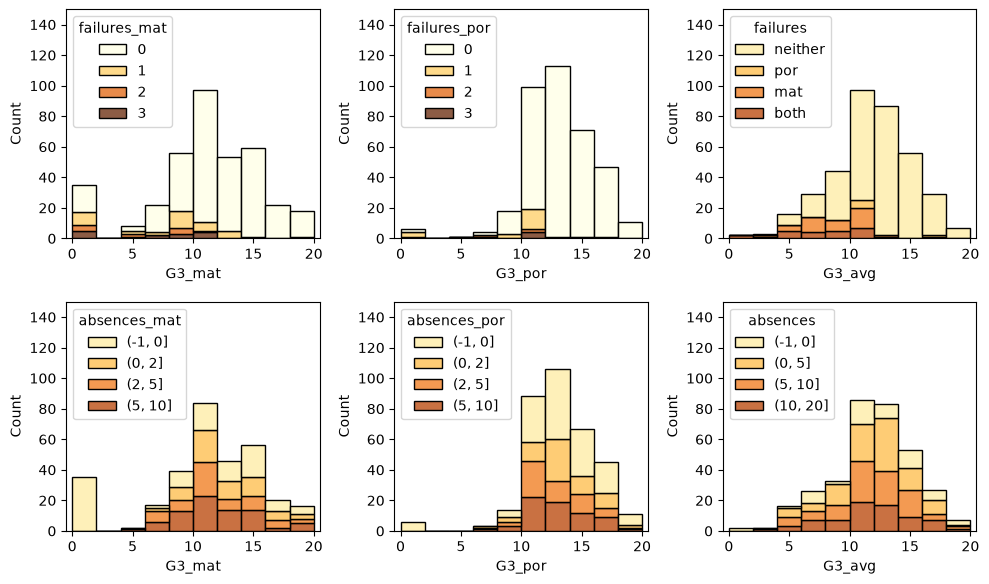

In [66]:
f, axes = plt.subplots(2, 3)
for si, suff in enumerate(["_mat", "_por"]):
    seaborn.histplot(x=spmandp_dtf["G3"+suff], hue=spmandp_dtf["failures"+suff], palette="YlOrBr",
                     binwidth=2, binrange=(0,20), multiple="stack", ax=axes[0,si])
    axes[0,si].set_xlim([-0.5,20.5])
    axes[0,si].set_ylim([0,150])
    absence_cats = pandas.cut(spmandp_dtf["absences"+suff], [-1,0,2,5,10])
    seaborn.histplot(x=spmandp_dtf["G3"+suff],  hue=absence_cats, palette="YlOrBr",
                     binwidth=2, binrange=(0,20), multiple="stack", ax=axes[1,si])
    axes[1,si].set_xlim([-0.5,20.5])
    axes[1,si].set_ylim([0,150])

si = -1
seaborn.histplot(x=spmandp_dtf["G3_avg"],
                hue=spmandp_dtf["failures"], hue_order=["neither", "por", "mat", "both"], palette="YlOrBr",
                binwidth=2, binrange=(0,20), multiple="stack", ax=axes[0,si])
axes[0,si].set_xlim([-0.5,20.5])
axes[0,si].set_ylim([0,150])
absence_cats = pandas.cut(spmandp_dtf["absences"], [-1,0,5,10,20])
seaborn.histplot(x=spmandp_dtf["G3_avg"], hue=absence_cats, palette="YlOrBr",
                binwidth=2, binrange=(0,20), multiple="stack", ax=axes[1,si])
axes[1,si].set_xlim([-0.5,20.5])
axes[1,si].set_ylim([0,150])
f.set_figheight(6)
f.tight_layout()

We see that students with past failures in a topic tend to receive lower final grades on that topic. On the other hand, the distribution of grades is more similar across groups of students with different amounts of absences. This is in line with our previous observations from the correlation matrix.

Finally, we draw box plots of the average of final grades while grouping students according to the values of different attributes in turn. The number of students in each group is indicated under the corresponding box plot.
We do not consider attributes that have a single dominant value, nor the grade attributes, which we already analyzed in some details previously.

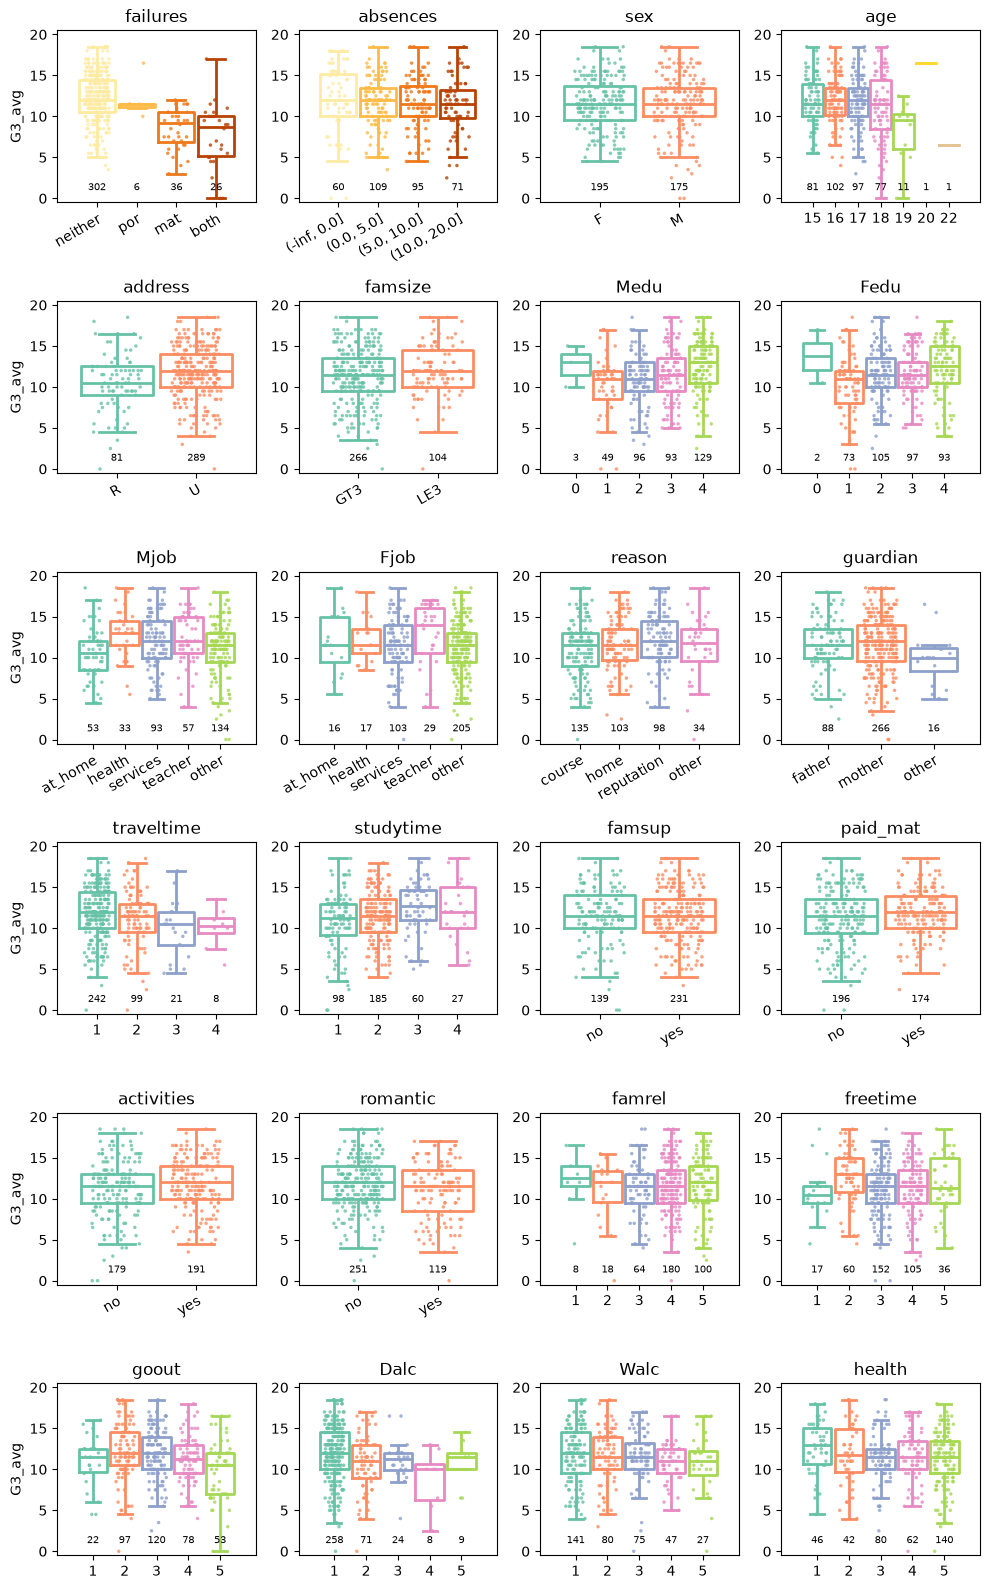

In [67]:
def lmbd_sort_index_otherlast(idx):
    ### to ensure that the 'other' group is the right-most box plot
    return idx.map(lambda x: "zzz" if x == "other" else x)

columns_to_plot = ["failures", "absences"]+[col["name"] for (cid, col) in cols.iterrows()
                   if col["freq"] < 0.8 # and col["nb_represent"] < 5 and
                   and not col["name"].startswith("G") and not col["name"].startswith("index")
                        and "absence" not in col["name"] and "failure" not in col["name"]]

per_row = 4
f, axes = plt.subplots(6, per_row)
for ci, colname in enumerate(columns_to_plot):
    if colname == "failures":
        v_rep = colname
        vs = ["neither", "por", "mat", "both"]
        cs = spmandp_dtf[colname].value_counts().loc[vs].to_list()
        kwargs = {"hue_order": vs, "palette": "YlOrBr"}
    elif colname == "absences":
        v_rep = pandas.cut(spmandp_dtf[colname], [float("-Inf"),0,5,10,20])
        vs, cs = map(list, zip(*v_rep.value_counts().sort_index().items()))
        kwargs = {"hue_order": vs, "palette": "YlOrBr"}
    else:
        v_rep = colname
        vs, cs = map(list, zip(*spmandp_dtf[colname].value_counts()\
                               .sort_index(key=lmbd_sort_index_otherlast).items()))
        kwargs = {"hue_order": vs, "palette": "Set2"}

    seaborn.stripplot(spmandp_dtf, y="G3_avg", hue=v_rep, alpha=0.8, size=2.5,
                    ax=axes[ci//per_row, ci%per_row], dodge=True, jitter=.25,# width=1, gap=0.1,
                    legend=False, **kwargs)
    seaborn.boxplot(spmandp_dtf, y="G3_avg", hue=v_rep, fill=False, linewidth=2, showfliers=False,
                    ax=axes[ci//per_row, ci%per_row], dodge=True, width=0.8, gap=0.1,
                    legend=False, **kwargs)

    tick_pos = .8*((1+2*numpy.arange(len(vs)))/(2*len(vs))-0.5)
    if all([type(v) is int for v in vs]):
        axes[ci//per_row, ci%per_row].set_xticks(tick_pos, vs)
    else:
        axes[ci//per_row, ci%per_row].set_xticks(tick_pos, vs, rotation=30, ha="right", rotation_mode="anchor")
    for i, tpos in enumerate(tick_pos):
        axes[ci//per_row, ci%per_row].text(tpos, 1, cs[i], horizontalalignment="center", size="x-small")
    axes[ci//per_row, ci%per_row].set_ylim([-.5, 20.5])
    if ci%per_row > 0:
        axes[ci//per_row, ci%per_row].set_ylabel("")
    axes[ci//per_row, ci%per_row].set_title(colname)
f.set_figheight(16)
f.tight_layout()

Again, as expected from previous observations, more failures are associated with lower grades, whereas there is no such strong association between absences and grades.

There are about twenty more female students than male students (195 rows with `sex` value `F` vs. 175 rows with `sex` value `M`). Both groups have fairly similar grade distributions.

A large majority of students have urban addresses (289 rows with `address` value `U`). The median grade is lower for the minority of students with a rural address (81 rows with `address` value `R`).

We give the clarification of all attributes values, for further interpretation of the above figures.

- **school**: student's school
	- **GP**: *Gabriel Pereira*
	- **MS**: *Mousinho da Silveira*
- **sex**: student's sex
	- **F**emale
	- **M**ale
- **age**: student's age, from 15 to 22
- **address**: student's home address type
	- **U**rban
	- **R**ural
- **famsize**: family size
	- **LE3**: less or equal to 3
	- **GT3**: greater than 3
- **Pstatus**: parent's cohabitation status
	- **T**: living together
	- **A**: apart
- **Medu/Fedu**: mother's/father's education
	- **0**: none
	- **1**: primary education (4th grade)
	- **2**: 5th to 9th grade
	- **3**: secondary education
	- **4**: higher education
- **Mjob/Fjob**: mother's/father's job
	- **teacher**
	- **health**care related
	- civil **services** (e.g. administrative or police)
	- **at home**
	- **other**
- **reason**: reason to choose this school
	- close to **home**
	- school **reputation**
	- **course** preference
	- **other**
- **guardian**: student's guardian,
	- **mother**
	- **father**
	- **other**
- **traveltime**: home to school travel time
	- **1**: <15 min.
	- **2**: 15 to 30 min.
	- **3**: 30 min. to 1 hour
	- **4**: >1 hour
- **studytime**: weekly study time
	- **1**: <2 hours
	- **2**: 2 to 5 hours
	- **3**: 5 to 10 hours
	- **4**: >10 hours
- **failures**: number of past class failures, n if 1<=n<3, else 4
- **schoolsup**: extra educational support, yes/no
- **famsup**: family educational support, yes/no
- **paid**: extra paid classes within the course subject (Math or Portuguese), yes/no
- **activities**: extra-curricular activities, yes/no
- **nursery**: attended nursery school, yes/no
- **higher**: wants to take higher education, yes/no
- **internet**: Internet access at home, yes/no
- **romantic**: with a romantic relationship, yes/no
- **famrel**: quality of family relationships, from very bad (1) to excellent (5)
- **freetime**: free time after school, from very low (1) to very high (5)
- **goout**: going out with friends, from very low (1) to very high (5)
- **Dalc**: workday alcohol consumption, from very low (1) to very high (5)
- **Walc**: weekend alcohol consumption, from very low (1) to very high (5)
- **health**: current health status, from very bad (1) to very good (5)
- **absences**: number of school absences
- **G1**: first period grade, from 0 to 20
- **G2**: second period grade, from 0 to 20
- **G3**: final grade, from 0 to 20, output target